### Importando bibliotecas necessárias

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch
import matplotlib.cm as cm

### Carregando o arquivo CSV e verificando as primeiras linhas do DataFrame

In [23]:
df = pd.read_csv('respostas_questionario.csv')
df.head()

,Carimbo de data/hora,Endereço de e-mail,"Declaração de suficiência dos esclarecimentos sobre a pesquisa:\r\nDeclaro que li as informações contidas nesse documento, fui devidamente informado(a) pelo(a) pesquisador (a) sobre os procedimentos que serão utilizados, riscos e desconfortos, benefícios, custo/reembolso dos participantes, confidencialidade da pesquisa, concordando ainda em participar da pesquisa. Foi-me garantido que posso retirar o consentimento a qualquer momento, sem qualquer penalidade ou prejuízo. Poderei consultar o pesquisador responsável (acima identificado) ou com o Comitê de Ética em Pesquisa com Seres Humanos do Campus Araguaia (CEP/ARAGUAIA), E-mail: cephumanos.cua@ufmt.br.com; Fone: (66) 3402-0744, sempre que entender necessário obter informações ou esclarecimentos sobre o projeto de pesquisa e minha participação no mesmo. Os resultados obtidos durante este estudo serão mantidos em sigilo, mas concordo que sejam divulgados em publicações científicas, desde que meus dados pessoais não sejam mencionados.","Declaro que li o Termo de Consentimento Livre e Esclarecido (TCLE) e que concordo em participar, como voluntário(a), da pesquisa descrita:","Declaro que faço parte do público alvo do estudo e contemplo todas as seguintes condições:\r\n\r\n- Assinalar ""Sim"" nas duas declarações iniciais; \r\n- Ter idade de 18 anos ou mais;\r\n- Ser discente/estudante de qualquer instituição de ensino superior na região de Barra do Garças - MT.",Qual o seu gênero?,A instituição em que você estuda é pública ou particular?,De qual área da sua instituição você pertence?,A qual curso você pertence?,Em qual semestre você está?,...,Com qual frequência você utiliza sistemas baseados em IA generativa em suas atividades acadêmicas?,"Você considera a interação IA e acadêmicos positiva, negativa ou neutra? Por quê?",Quão familiar você se considera com as capacidades da IA generativa? (0 para pouco e 5 para muito),Você acredita que o uso da IA generativa pode comprometer a autenticidade do seu trabalho acadêmico?,"Na sua experiência, a IA generativa tem sido eficiente nas suas atividades acadêmicas?","Se sim, por que você considera a IA generativa eficiente em suas atividades acadêmicas?",Você acredita que a IA generativa é melhor que os métodos tradicionais ?,"Se sim, selecione os motivos que justificam por que a IA Generativa é considerada melhor que os métodos tradicionais","No geral, como você avalia sua experiência ao utilizar ferramentas de IA generativa no ensino superior?",Você tem alguma sugestão ou comentário adicional sobre o uso de ferramentas de IA generativa na educação superior? (Resposta aberta)
0,30/07/2024 13:29:15,wesley.santos@sou.ufmt.br,"Sim, assim eu declaro.","Sim, aceito participar como voluntário na pesq...","Sim, assim eu declaro.",Masculino,Pública,Ciências Exatas e da Terra,Ciência da Computação,9º Semestre,...,Raramente,Positiva,0,Talvez,Sim,Auxilia em correções principalmente de textos,Não,NaN,Parcialmente Satisfeito,NaN
1,30/07/2024 13:34:26,evelynfelix515@gmail.com,"Sim, assim eu declaro.","Sim, aceito participar como voluntário na pesq...","Sim, assim eu declaro.",Feminino,Pública,"Linguística, Letras e Artes",Letras,5° Semestre,...,Mensalmente,Neutra. Pois otimiza tempo se você souber usar...,4,Talvez,Não,NaN,Não,NaN,Parcialmente Satisfeito,NaN
2,30/07/2024 13:38:37,nathalia.santos1@sou.ufmt.br,"Sim, assim eu declaro.","Sim, aceito participar como voluntário na pesq...","Sim, assim eu declaro.",Feminino,Pública,Ciências Exatas e da Terra,Engenharia Civil,7° Semestre,...,Raramente,"Neutra, ela auxilia para que os prazos sejam c...",1,Não,Não,NaN,Parcialmente,"Eficiência na Geração de Conteúdo, Variedade d...",Satisfeito,NaN
3,30/07/2024 13:49:30,amandabiomed2019@gmail.com,"Sim, assim eu declaro.","Sim, aceito participar como voluntário na pesq...","Sim, assim eu declaro.",Feminino,Pública,Ciências da Saúde,Biomedicina,4° Semestre,...,Semanalmente,Acredito que a característica da interação aca...,3,Si

# Análise Das Perguntas Demográficas com base nas áreas de estudo

### Área de Estudo

In [24]:
# Dicionário para agrupar as áreas (mantendo a capitalização correta)
areas_agrupadas = {
    'Ciências Agrárias': 'Ciências Agrárias',
    'Linguística, Letras e Artes': 'Ciências Humanas e Sociais',
    'Agronomia': 'Ciências Agrárias',
    'Ciências Biológicas': 'Ciências Biológicas',
    'Ciências da Saúde': 'Ciências Biológicas',
    'Educação física': 'Ciências Biológicas',
    'Ciências Exatas e da Terra': 'Ciências Exatas e da Terra',
    'Engenharias': 'Ciências Exatas e da Terra',
    'Ciências Humanas': 'Ciências Humanas e Sociais',
    'Ciências Sociais Aplicadas': 'Ciências Humanas e Sociais',
    'Direito': 'Ciências Humanas e Sociais',
    'DIREITO': 'Ciências Humanas e Sociais',
    'Linguística, Letras e Artes': 'Ciências Humanas e Sociais'
}

# Remover espaços extras
df['De qual área da sua instituição você pertence?'] = df['De qual área da sua instituição você pertence?'].str.strip()

# Aplicar a substituição e agrupar
df['Área de Estudo Agrupada'] = df['De qual área da sua instituição você pertence?'].replace(areas_agrupadas)

# Verificar áreas não mapeadas
areas_nao_mapeadas = df[~df['De qual área da sua instituição você pertence?'].isin(areas_agrupadas.keys())]
print("Áreas não mapeadas:", areas_nao_mapeadas['De qual área da sua instituição você pertence?'].unique())

# Calcular a contagem de ocorrências de cada área de estudo agrupada
contagem_areas_agrupadas = df['Área de Estudo Agrupada'].value_counts().reset_index()

# Ajustar o nome das colunas
contagem_areas_agrupadas.columns = ['Área de Estudo Agrupada', 'Contagem']

print(contagem_areas_agrupadas)

# Total de respostas
total_respostas = contagem_areas_agrupadas['Contagem'].sum()
print(f"Total de respostas: {total_respostas}")

# Porcentagem ao lado de cada área de estudo agrupada
print("\nNúmero de respostas por área de estudo agrupada e porcentagem ao lado:")
for area, contagem in zip(contagem_areas_agrupadas['Área de Estudo Agrupada'], contagem_areas_agrupadas['Contagem']):
    porcentagem = (contagem / contagem_areas_agrupadas['Contagem'].sum()) * 100
    print(f"{area}: {contagem} ({porcentagem:.1f}%)")

# Corrigir manualmente o curso de Agronomia para a área correta
df.loc[df['A qual curso você pertence?'].str.contains('Agronomia', case=False, na=False), 'Área de Estudo Agrupada'] = 'Ciências Agrárias'

# Corrigir a área de Psicologia para Ciências Humanas e Sociais
df.loc[df['A qual curso você pertence?'].str.contains('Psicologia', case=False, na=False), 'Área de Estudo Agrupada'] = 'Ciências Humanas e Sociais'

Áreas não mapeadas: []
      Área de Estudo Agrupada  Contagem
0  Ciências Humanas e Sociais        49
1  Ciências Exatas e da Terra        28
2         Ciências Biológicas        24
3           Ciências Agrárias        22
Total de respostas: 123

Número de respostas por área de estudo agrupada e porcentagem ao lado:
Ciências Humanas e Sociais: 49 (39.8%)
Ciências Exatas e da Terra: 28 (22.8%)
Ciências Biológicas: 24 (19.5%)
Ciências Agrárias: 22 (17.9%)


C:\Users\Luise\AppData\Local\Temp\ipykernel_16992\1223255455.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap('viridis')


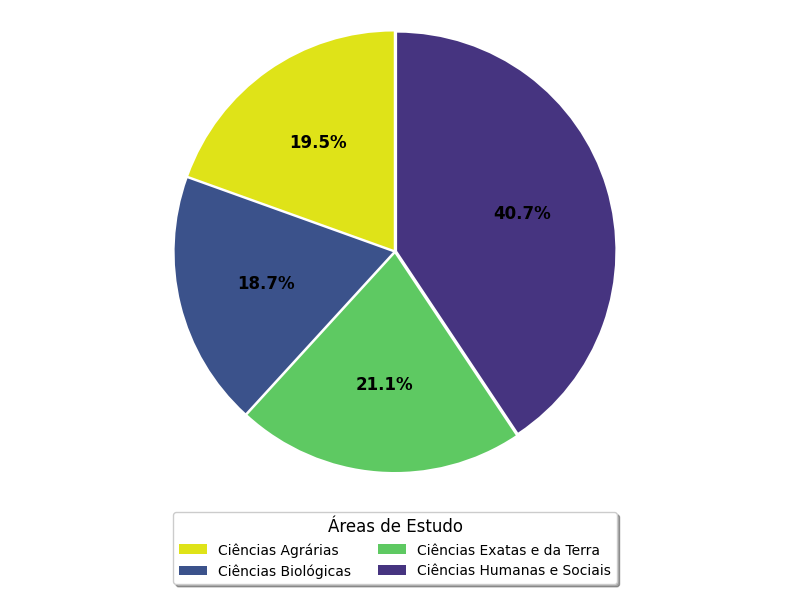

In [25]:
# Agrupar os dados por 'Área de Estudo Agrupada' e calcular a contagem total
df_grouped_areas = df.groupby('Área de Estudo Agrupada').size().reset_index(name='Contagem')

# Extrair os dados para o gráfico
labels = df_grouped_areas['Área de Estudo Agrupada']  # Nomes das áreas agrupadas
sizes = df_grouped_areas['Contagem'] / df_grouped_areas['Contagem'].sum() * 100  # Porcentagens

# Especificar cores da paleta viridis
viridis = cm.get_cmap('viridis')
colors = [viridis(0.95), viridis(0.25), viridis(0.75), viridis(0.15)]  # Valores específicos da paleta

# Criar o gráfico de pizza
fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    sizes, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors,
    # espaço entre todas as fatias
    explode=(0.01,) * len(sizes),
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# Personalizar os textos das porcentagens
for autotext in autotexts:
    autotext.set_color('black')  # Cor do texto
    autotext.set_fontsize(12)    # Tamanho da fonte
    autotext.set_fontweight('bold')  # Negrito

# Adicionar uma legenda
ax.legend(
    labels,
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.2), 
    ncol=2, 
    title='Áreas de Estudo', 
    title_fontsize=12, 
    fontsize=10,
    fancybox=True,
    shadow=True
)

# Garantir que o gráfico seja circular
ax.axis('equal')

# Exibir o gráfico
plt.tight_layout()
plt.show()

### Gênero

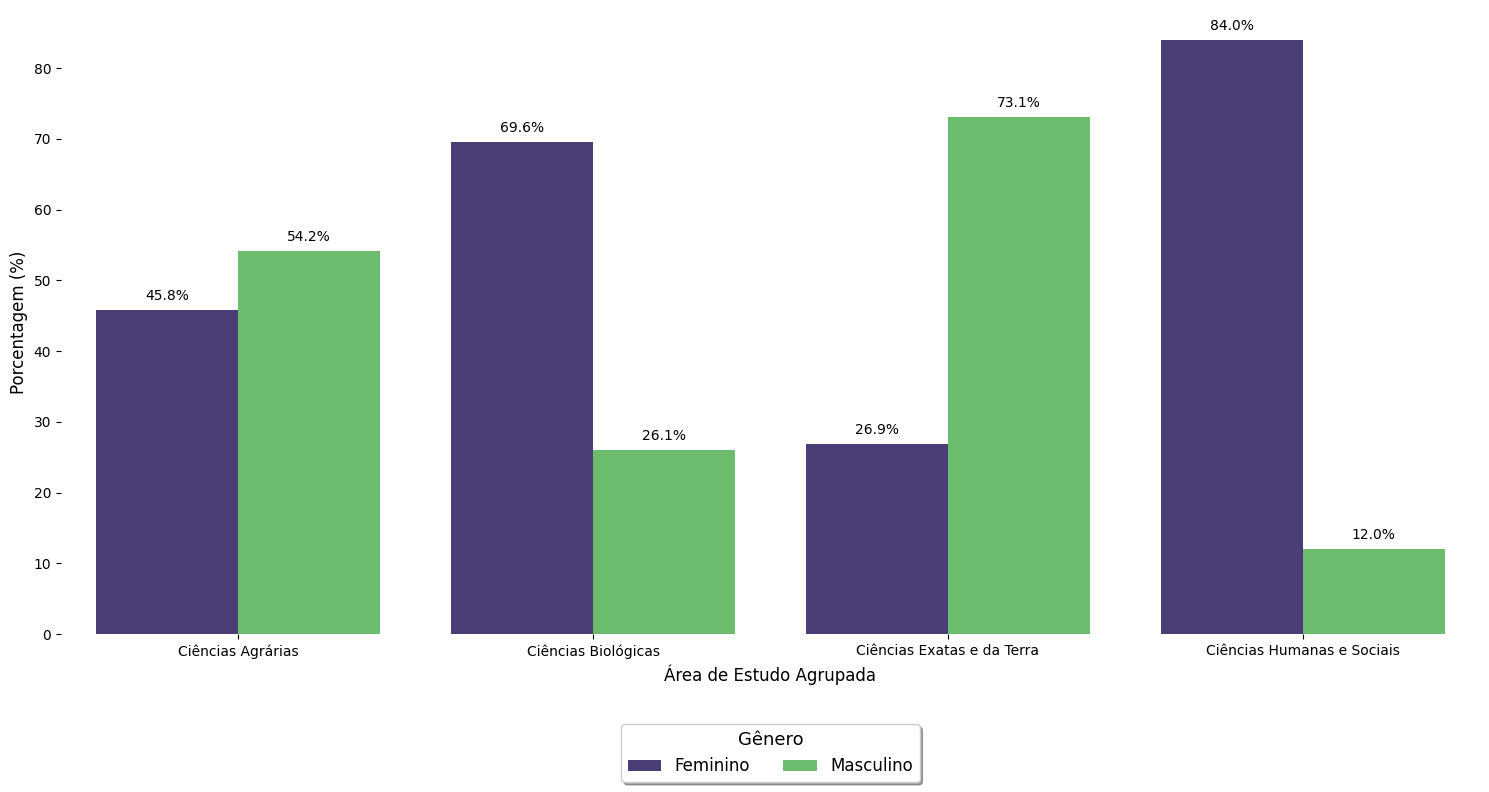

In [26]:
# Agrupar os dados por 'Área de Estudo Agrupada' e 'Gênero', calculando a contagem
df_grouped = df.groupby(['Área de Estudo Agrupada', 'Qual o seu gênero?']).size().reset_index(name='Contagem')

# Calcular a porcentagem de cada gênero dentro de cada área de estudo
df_grouped['Total_Area'] = df_grouped.groupby('Área de Estudo Agrupada')['Contagem'].transform('sum')
df_grouped['Percentual'] = (df_grouped['Contagem'] / df_grouped['Total_Area']) * 100

# Filtrar os dados para remover combinações com contagem zero
df_grouped = df_grouped[df_grouped['Contagem'] > 0]

# Ordenar os valores de 'Qual o seu gênero' para garantir a ordem correta na legenda
df_grouped['Qual o seu gênero?'] = pd.Categorical(
    df_grouped['Qual o seu gênero?'],
    categories=['Feminino', 'Masculino'],
    ordered=True
)

# Definir cores da paleta viridis
# Cores para Feminino, Masculino e Prefiro não dizer
viridis = plt.cm.viridis
colors = { 'Feminino': viridis(0.15), 'Masculino': viridis(0.75)}  

# Criar o gráfico de barras
plt.figure(figsize=(15, 8))
ax = sns.barplot(
    data=df_grouped, 
    x='Área de Estudo Agrupada', 
    y='Percentual', 
    hue='Qual o seu gênero?', 
    palette=colors  # Usar as cores da paleta viridis
)

# Adicionar rótulos de porcentagem acima das barras
# Adicionar os percentuais sobre as barras
for patch, row in zip(ax.patches, df_grouped.itertuples()):
    x = patch.get_x() + patch.get_width() / 2.0
    y = patch.get_height()
    if y > 0:  # Adicionar texto apenas para barras com altura maior que 0
        plt.text(x, y + 1, f'{y:.1f}%', ha='center', va='bottom', fontsize=10, color='black')



# Configurar título e rótulos dos eixos
# plt.title('Porcentagem de Gêneros por Área de Estudo Agrupada', fontsize=16, fontweight='bold')
plt.xlabel('Área de Estudo Agrupada', fontsize=12)
plt.ylabel('Porcentagem (%)', fontsize=12)


legend_elements = [
    Patch(facecolor=colors['Feminino'], label='Feminino'),  # Cor para Feminino
    Patch(facecolor=colors['Masculino'], label='Masculino')  # Cor para Masculino
]

# Ajustar a legenda
plt.legend(
    title='Gênero', 
    loc='lower center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=2,
    fancybox=True,
    shadow=True, 
    fontsize=12, 
    title_fontsize=13)

# Ajustar layout
plt.tight_layout()

# Retirar o box
plt.box(False)
plt.grid(False)

# Exibir o gráfico
plt.show()

### Instituição (Pública ou Privada)

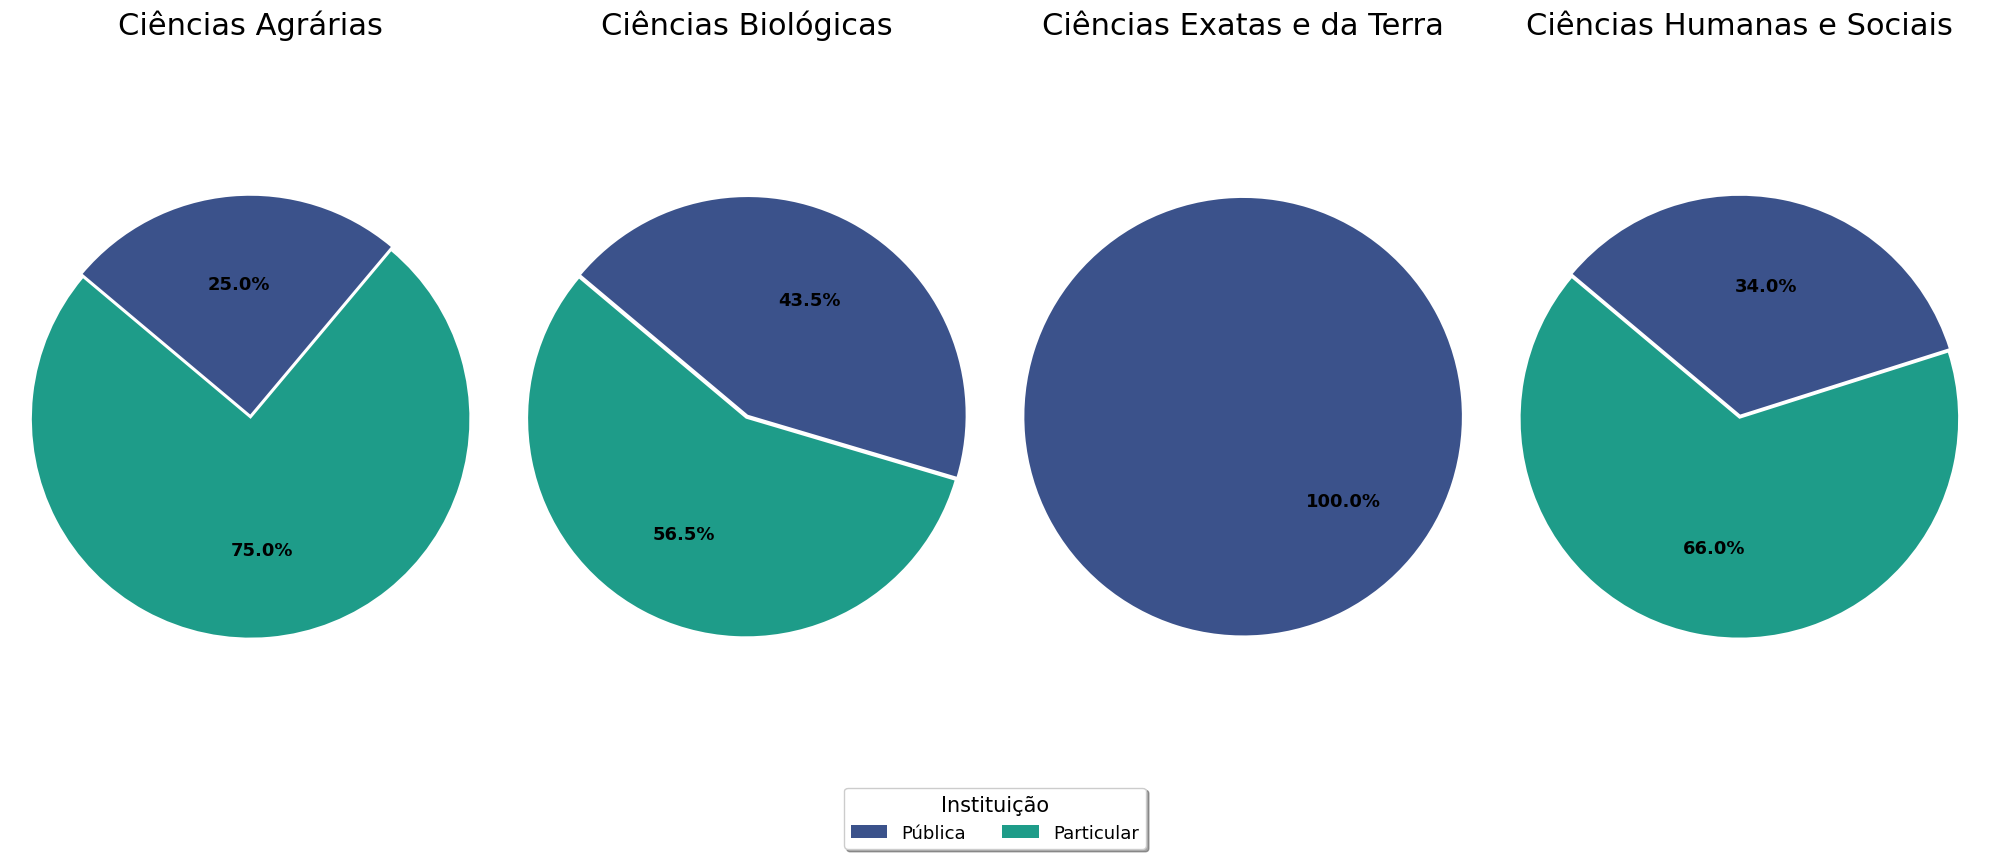

In [27]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import pandas as pd

# Agrupar os dados
df_grouped_instituicao = df.groupby(['Área de Estudo Agrupada', 'A instituição em que você estuda é pública ou particular?']).size().reset_index(name='Contagem')
df_grouped_instituicao['Total_Area'] = df_grouped_instituicao.groupby('Área de Estudo Agrupada')['Contagem'].transform('sum')
df_grouped_instituicao['Percentual'] = (df_grouped_instituicao['Contagem'] / df_grouped_instituicao['Total_Area']) * 100
df_grouped_instituicao = df_grouped_instituicao[df_grouped_instituicao['Contagem'] > 0]

# Ordenar os valores para a legenda
df_grouped_instituicao['A instituição em que você estuda é pública ou particular?'] = pd.Categorical(
    df_grouped_instituicao['A instituição em que você estuda é pública ou particular?'],
    categories=['Pública', 'Particular'],
    ordered=True
)

# Definir cores
viridis = plt.cm.viridis
colors_instituicao = {'Pública': viridis(0.25), 'Particular': viridis(0.55)}

# Criar os gráficos de pizza lado a lado
areas_unicas = df_grouped_instituicao['Área de Estudo Agrupada'].unique()
fig, axes = plt.subplots(1, len(areas_unicas), figsize=(20, 8))

for ax, area in zip(axes, areas_unicas):
    dados_area = df_grouped_instituicao[df_grouped_instituicao['Área de Estudo Agrupada'] == area]

    # Pizza
    wedges, texts, autotexts = ax.pie(
        dados_area['Percentual'], 
        labels=None,  # Remove os labels ao lado da pizza
        autopct='%1.1f%%',
        startangle=140,
        colors=[colors_instituicao[tipo] for tipo in dados_area['A instituição em que você estuda é pública ou particular?']],
        # coloca um espaço entre as fatias
        explode=(0.01,) * len(dados_area),
        textprops={'fontsize': 12, 'fontweight': 'bold'}
    )

    # Estética dos textos
    for autotext in autotexts:
        autotext.set_fontsize(13)
        autotext.set_fontweight('bold')

    # Título centralizado para cada gráfico
    ax.set_title(area, fontsize=22, pad=15)
    ax.axis('equal')

# Legenda fora do gráfico
legend_elements = [
    Patch(facecolor=colors_instituicao['Pública'], label='Pública'),
    Patch(facecolor=colors_instituicao['Particular'], label='Particular')
]

fig.legend(
    handles=legend_elements,
    title='Instituição',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    fancybox=True,
    shadow=True,
    fontsize=13,
    title_fontsize=15
)

plt.tight_layout()
plt.show()

### Cursos

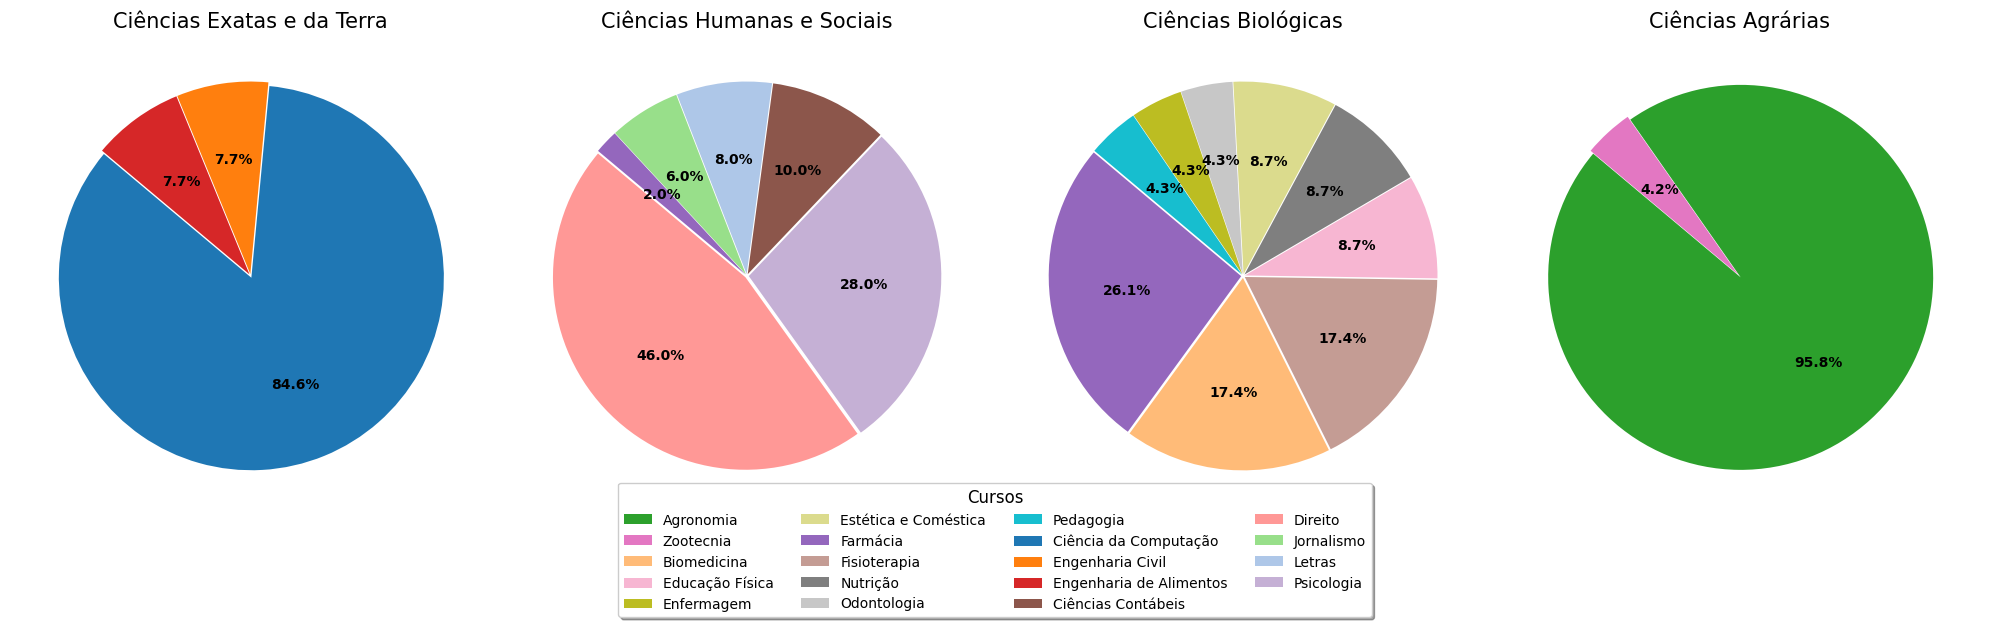

Área: Ciências Agrárias
Cursos: ['Agronomia' 'Zootecnia']
Porcentagem de cada curso:
  Agronomia: 18.7%
  Zootecnia: 0.8%

Área: Ciências Biológicas
Cursos: ['Biomedicina' 'Farmácia' 'Fisioterapia' 'Educação Física' 'Nutrição'
 'Odontologia' 'Enfermagem' 'Estética e Coméstica' 'Pedagogia']
Porcentagem de cada curso:
  Biomedicina: 3.3%
  Farmácia: 5.7%
  Fisioterapia: 3.3%
  Educação Física: 1.6%
  Nutrição: 1.6%
  Odontologia: 0.8%
  Enfermagem: 0.8%
  Estética e Coméstica: 1.6%
  Pedagogia: 0.8%

Área: Ciências Exatas e da Terra
Cursos: ['Ciência da Computação' 'Engenharia Civil' 'Engenharia de Alimentos']
Porcentagem de cada curso:
  Ciência da Computação: 17.9%
  Engenharia Civil: 1.6%
  Engenharia de Alimentos: 1.6%

Área: Ciências Humanas e Sociais
Cursos: ['Letras' 'Jornalismo' 'Direito' 'Psicologia' 'Farmácia'
 'Ciências Contábeis']
Porcentagem de cada curso:
  Letras: 3.3%
  Jornalismo: 2.4%
  Direito: 18.7%
  Psicologia: 11.4%
  Farmácia: 5.7%
  Ciências Contábeis: 4.1%



In [57]:
# Obter os cursos únicos do DataFrame
cursos_unicos = df['A qual curso você pertence?'].unique()

# Escolher uma paleta discreta com cores suficientes. Aqui usamos 'tab20'.
num_cores = len(cursos_unicos)
palette = sns.color_palette('tab20', num_cores)

# Criar um dicionário para associar cada curso a uma cor fixa
global_colors = {curso: palette[i] for i, curso in enumerate(cursos_unicos)}

# Criar um mapeamento de curso para área (usando o primeiro registro encontrado para cada curso)
curso_area = df.groupby('A qual curso você pertence?')['Área de Estudo Agrupada'].first().to_dict()

# Definir a ordem desejada das áreas
ordem_areas = {
    'Ciências Agrárias': 1,
    'Ciências Biológicas': 2,
    'Ciências Exatas e da Terra': 3,
    'Ciências Humanas e Sociais': 4
}

# Ordenar a lista de cursos com base na área e, dentro da mesma área, em ordem alfabética
cursos_ordenados = sorted(cursos_unicos, key=lambda curso: (ordem_areas.get(curso_area.get(curso, ""), 99), curso))

# Obter a lista de áreas únicas (para os gráficos)
areas_unicas = df['Área de Estudo Agrupada'].unique()

# Definir 1 linha e número de colunas igual ao número de áreas
n_colunas = len(areas_unicas)
n_linhas = 1

# Criar os subplots em linha única
fig, axs = plt.subplots(n_linhas, n_colunas, figsize=(5 * n_colunas, 6))
axs = axs.flatten()  # Facilitar o acesso aos eixos

# Gerar um gráfico de pizza por área de estudo
for i, area in enumerate(areas_unicas):
    df_area = df[df['Área de Estudo Agrupada'] == area]
    
    # Contar o número de respondentes por curso na área
    cursos_count = df_area['A qual curso você pertence?'].value_counts()
    
    # Obter as cores fixas para cada curso desta área, com base no dicionário global
    cores = [global_colors[curso] for curso in cursos_count.index]
    
    # Plotar o gráfico de pizza
    axs[i].pie(
        cursos_count,
        labels=None,  # Remove os labels externos da pizza
        autopct='%1.1f%%',
        startangle=140,
        textprops={'fontsize': 10, 'fontweight': 'bold'},
        colors=cores,
        explode=(0.01,) * len(cursos_count)
    )
    axs[i].set_title(f'{area}', fontsize=15)

# Criar a legenda global com os cursos ordenados (apenas o nome do curso)
legend_elements = [Patch(facecolor=global_colors[curso], label=curso) for curso in cursos_ordenados]
fig.legend(
    handles=legend_elements,
    title='Cursos',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=4,
    fancybox=True,
    shadow=True,
    fontsize=10,
    title_fontsize=12
)

# Ajuste final do layout e título
plt.tight_layout()
# plt.suptitle('Distribuição dos Cursos por Área de Estudo', fontsize=16, fontweight='bold', y=1.05)
plt.show()

# imprimir os cursos de cada área de estudo e sua porcentagem
areas_unicas = df['Área de Estudo Agrupada'].unique()
areas_unicas = sorted(areas_unicas, key=lambda x: ordem_areas.get(x, 99))

for area in areas_unicas:
    cursos_area = df[df['Área de Estudo Agrupada'] == area]['A qual curso você pertence?'].unique()
    print(f"Área: {area}")
    print("Cursos:", cursos_area)
    print("Porcentagem de cada curso:")
    for curso in cursos_area:
        porcentagem = (df[df['A qual curso você pertence?'] == curso].shape[0] / df.shape[0]) * 100
        print(f"  {curso}: {porcentagem:.1f}%")
    print()

### Semestre

C:\Users\Luise\AppData\Local\Temp\ipykernel_16992\1666999480.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap('tab10', len(sorted_semestres))


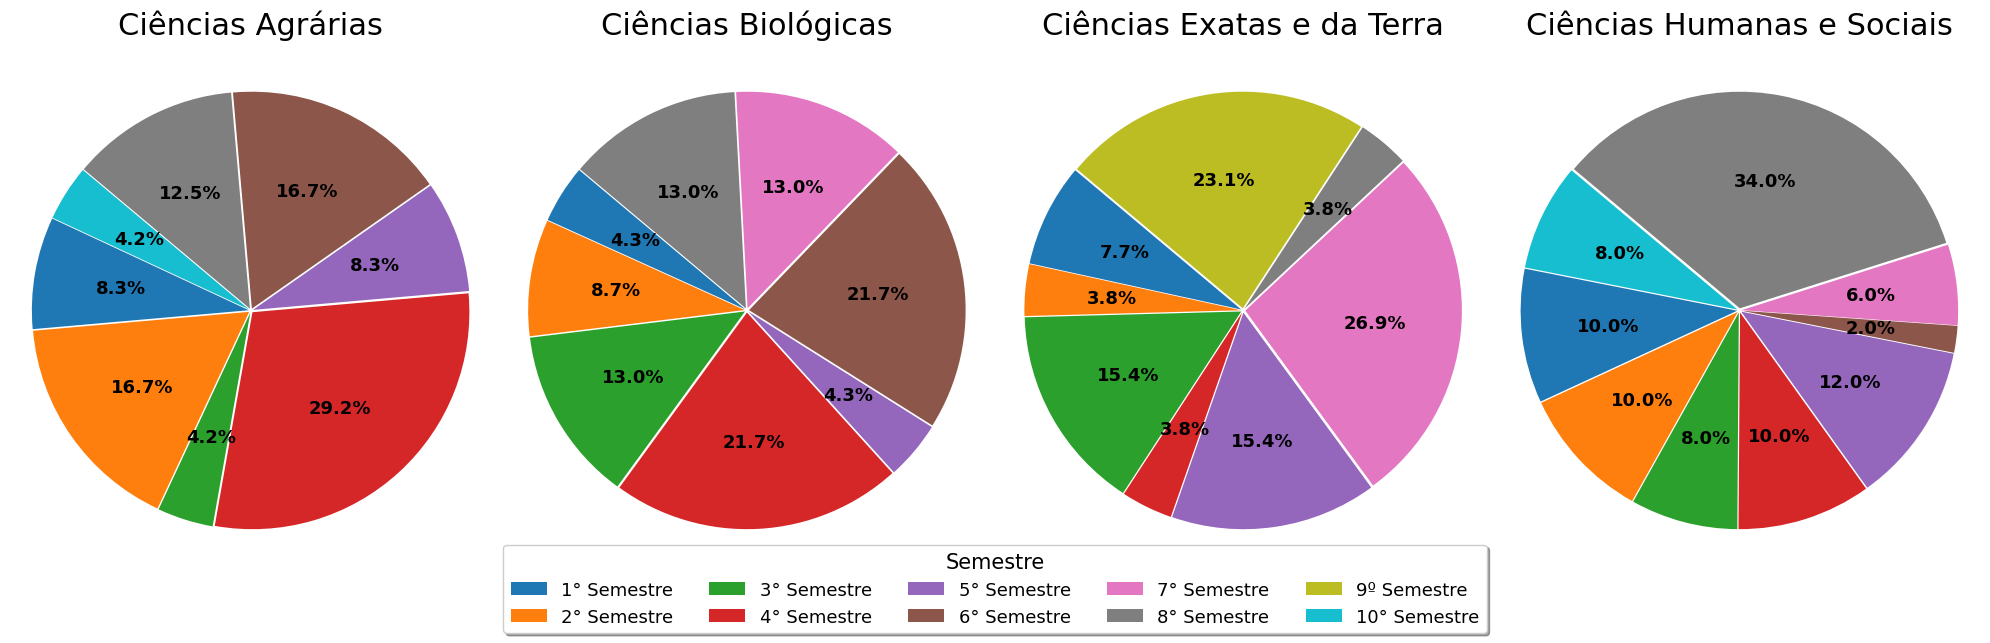

       Área de Estudo Agrupada Em qual semestre você está?  Contagem  \
0            Ciências Agrárias                10° Semestre         1   
1            Ciências Agrárias                 1° Semestre         2   
2            Ciências Agrárias                 2° Semestre         4   
3            Ciências Agrárias                 3° Semestre         1   
4            Ciências Agrárias                 4° Semestre         7   
5            Ciências Agrárias                 5° Semestre         2   
6            Ciências Agrárias                 6° Semestre         4   
7            Ciências Agrárias                 8° Semestre         3   
8          Ciências Biológicas                 1° Semestre         1   
9          Ciências Biológicas                 2° Semestre         2   
10         Ciências Biológicas                 3° Semestre         3   
11         Ciências Biológicas                 4° Semestre         5   
12         Ciências Biológicas                 5° Semestre      

In [55]:
import re

# Obter os semestres únicos
semestres_unicos = df_grouped_semestre['Em qual semestre você está?'].unique()

# Ordenar os semestres extraindo o número com regex
sorted_semestres = sorted(semestres_unicos, key=lambda s: int(re.search(r'\d+', s).group()))

# Gerar cores únicas para cada semestre usando a paleta 'tab10' com base nos semestres ordenados
viridis = cm.get_cmap('tab10', len(sorted_semestres))
cores_semestres = {semestre: viridis(i / len(sorted_semestres)) for i, semestre in enumerate(sorted_semestres)}

# Restante do código permanece inalterado...
n_colunas = len(df_grouped_semestre['Área de Estudo Agrupada'].unique())
fig, axes = plt.subplots(1, n_colunas, figsize=(5 * n_colunas, 6))

for ax, area in zip(axes, df_grouped_semestre['Área de Estudo Agrupada'].unique()):
    dados_area_semestre = df_grouped_semestre[df_grouped_semestre['Área de Estudo Agrupada'] == area]
    cores = [cores_semestres[semestre] for semestre in dados_area_semestre['Em qual semestre você está?']]
    wedges, texts, autotexts = ax.pie(
        dados_area_semestre['Percentual'], 
        labels=None,
        autopct='%1.1f%%',
        startangle=140,
        colors=cores,
        explode=(0.01,) * len(dados_area_semestre),
        textprops={'fontsize': 12, 'fontweight': 'bold'}
    )
    for autotext in autotexts:
        autotext.set_fontsize(13)
        autotext.set_fontweight('bold')
    ax.set_title(area, fontsize=22)
    ax.axis('equal') 

legend_elements = [
    Patch(facecolor=cores_semestres[semestre], label=semestre) for semestre in sorted_semestres
]

fig.legend(
    handles=legend_elements,
    title='Semestre',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=5,
    fancybox=True,
    shadow=True,
    fontsize=13,
    title_fontsize=15
)

plt.tight_layout()
plt.show()

print(df_grouped_semestre[['Área de Estudo Agrupada', 'Em qual semestre você está?', 'Contagem', 'Percentual']])


# Experiência com IAG

### Experiência Pessoal

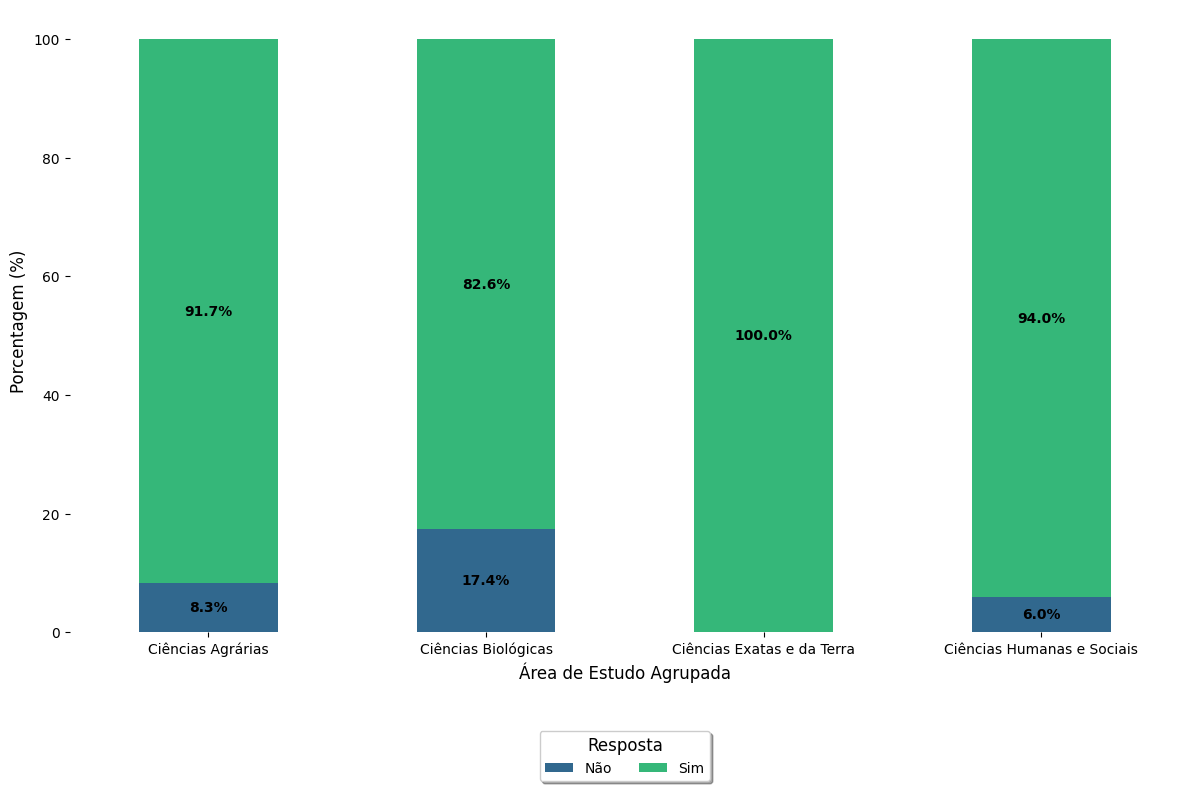


Porcentagem de experiência pessoal com IA Generativa por área de estudo:
Você já teve contato ou experiência com alguma ferramenta de Inteligência Artificial Generativa? Seja por lazer, curiosidade, etc        Não  \
Área de Estudo Agrupada                                                                                                                        
Ciências Agrárias                                                                                                                   8.333333   
Ciências Biológicas                                                                                                                17.391304   
Ciências Exatas e da Terra                                                                                                               NaN   
Ciências Humanas e Sociais                                                                                                          6.000000   

Você já teve contato ou experiência com alguma ferramenta de 

In [65]:
# Corrigir nomes das colunas, se necessário
df.columns = df.columns.str.strip()
coluna_experienciapessoal_ia = coluna_experienciapessoal_ia.strip()

# Calcular a porcentagem de experiência pessoal por área
experiencia_por_area = df.groupby('Área de Estudo Agrupada')[coluna_experienciapessoal_ia].value_counts(normalize=True).unstack() * 100

# Criar a paleta de cores
cores_viridis = sns.color_palette("viridis", len(experiencia_por_area.columns))

# Criar o gráfico de barras empilhadas
ax = experiencia_por_area.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 8), 
    color=cores_viridis
)

# Adicionar rótulos de porcentagem maiores que 0
for container in ax.containers:
    labels = [
        f'{v:.1f}%' if v > 0 else ''  # mostra somente se for > 0
        for v in container.datavalues
    ]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=10, fontweight='bold')

# Título e eixos
# plt.title('Porcentagem de Experiência Pessoal com IA Generativa por Área de Estudo', fontsize=16, fontweight='bold')
plt.xlabel('Área de Estudo Agrupada', fontsize=12)
plt.xticks(rotation=0, ha='center')  # horizontal e centralizado
plt.ylabel('Porcentagem (%)', fontsize=12)

# Legenda
plt.legend(
    title='Resposta', 
    loc='lower center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=2, 
    fontsize=10, 
    title_fontsize=12, 
    fancybox=True, 
    shadow=True
)

# Limpar bordas e grade
plt.box(False)
plt.grid(False)

# Layout final
plt.tight_layout()

# Mostrar gráfico
plt.show()

# Mostrar dados
print("\nPorcentagem de experiência pessoal com IA Generativa por área de estudo:")
print(experiencia_por_area)

### Experiência Acadêmica

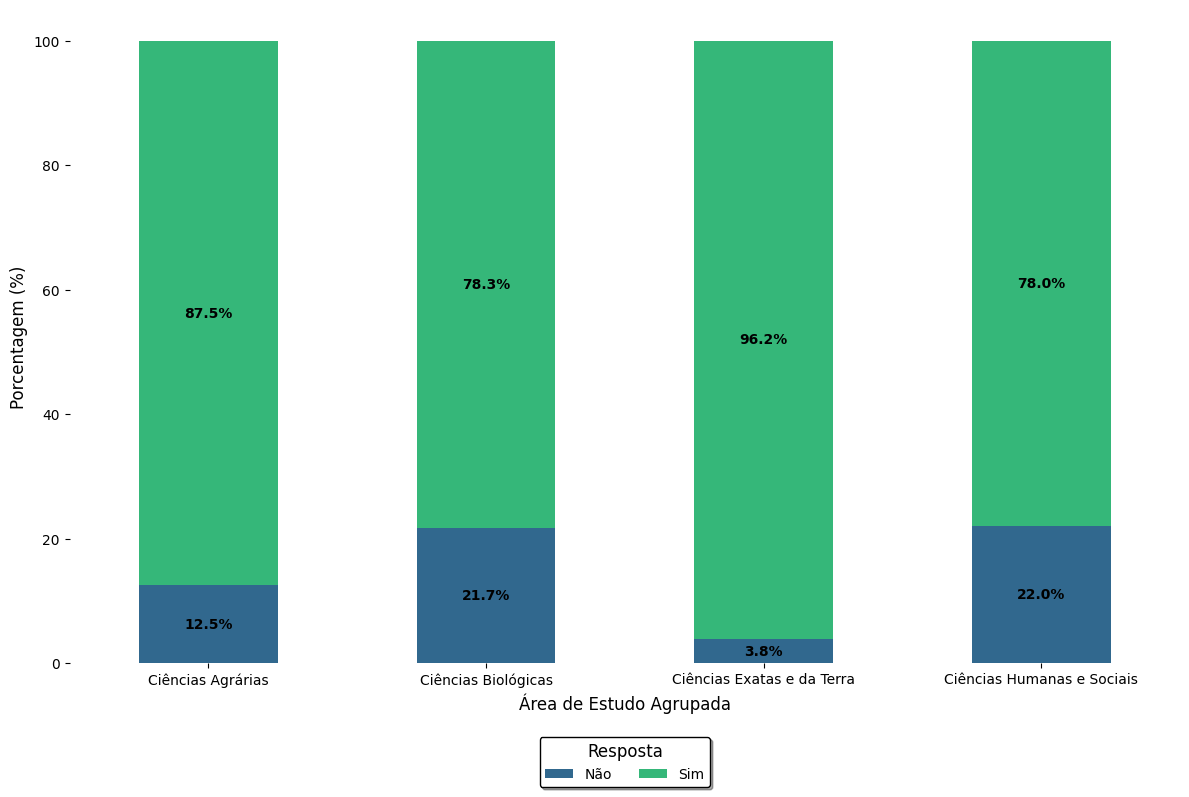


Porcentagem de experiência acadêmica com IA Generativa por área de estudo:
Você já teve contato ou experiência com alguma ferramenta de IA generativa com relação à sua área acadêmica? Para trabalhos acadêmicos ou trabalho profissional.        Não  \
Área de Estudo Agrupada                                                                                                                                                       
Ciências Agrárias                                                                                                                                                 12.500000   
Ciências Biológicas                                                                                                                                               21.739130   
Ciências Exatas e da Terra                                                                                                                                         3.846154   
Ciências Humanas e Sociais                       

In [ ]:
# Nome da coluna para análise
coluna_experiencia_academica = 'Você já teve contato ou experiência com alguma ferramenta de IA generativa com relação à sua área acadêmica? Para trabalhos acadêmicos ou trabalho profissional.'

# Corrigir nomes das colunas, se necessário
df.columns = df.columns.str.strip()

# Calcular a porcentagem de respostas por categoria
experiencia_academica = df[coluna_experiencia_academica].value_counts(normalize=True) * 100

# Criar a paleta de cores
cores_viridis = sns.color_palette("viridis", len(experiencia_academica))


# Criar patches para a legenda
legend_patches = [
    Patch(facecolor=cores_viridis[i], edgecolor='black', label=experiencia_academica.index[i])
    for i in range(len(experiencia_academica))
]

# Adicionar a legenda
# Agrupar os dados por 'Área de Estudo Agrupada' e calcular a porcentagem de respostas
experiencia_academica_por_area = df.groupby('Área de Estudo Agrupada')[coluna_experiencia_academica].value_counts(normalize=True).unstack() * 100

# Criar a paleta de cores
cores_viridis = sns.color_palette("viridis", len(experiencia_academica_por_area.columns))

# Criar o gráfico de barras empilhadas
ax = experiencia_academica_por_area.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 8), 
    color=cores_viridis
)

# Adicionar rótulos de porcentagem maiores que 0
for container in ax.containers:
    labels = [
        f'{v:.1f}%' if v > 0 else ''  # mostra somente se for > 0
        for v in container.datavalues
    ]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=10, fontweight='bold')

# Título e eixos
# plt.title('Porcentagem de Experiência com IAG para Fins Acadêmicos por Área de Estudo', fontsize=16, fontweight='bold')
plt.xlabel('Área de Estudo Agrupada', fontsize=12)
plt.xticks(rotation=0, ha='center')  # horizontal e centralizado
plt.ylabel('Porcentagem (%)', fontsize=12)

# Legenda
plt.legend(
    title='Resposta', 
    loc='lower center',
    bbox_to_anchor=(0.5, -0.20),
    ncol=2, 
    fontsize=10, 
    title_fontsize=12, 
    fancybox=True, 
    shadow=True,
)

# Limpar bordas e grade
plt.box(False)
plt.grid(False)

# Layout final
plt.tight_layout()

# Mostrar gráfico
plt.show()

# Mostrar dados de cada área de estudo e sua porcentagem 
print("\nPorcentagem de experiência acadêmica com IA Generativa por área de estudo:")
print(experiencia_academica_por_area)


### Motivos de Utilização de IAG para fins acadêmicos

C:\Users\Luise\AppData\Local\Temp\ipykernel_16992\921271228.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(motivos_atuais, fontsize=11)


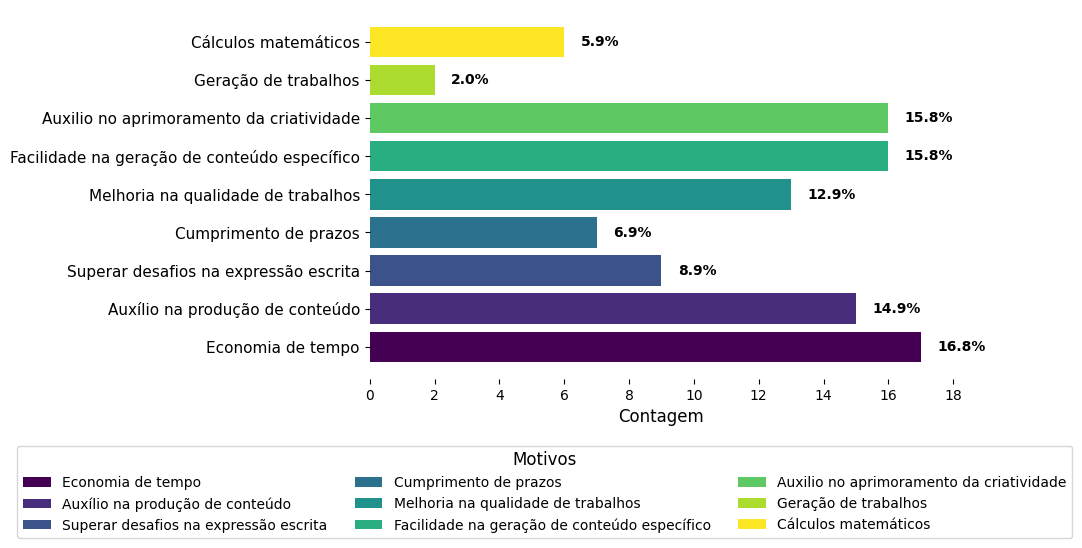


Motivos em Ciências Exatas e da Terra:
Economia de tempo: 17 (16.8%)
Auxílio na produção de conteúdo: 15 (14.9%)
Superar desafios na expressão escrita: 9 (8.9%)
Cumprimento de prazos: 7 (6.9%)
Melhoria na qualidade de trabalhos: 13 (12.9%)
Facilidade na geração de conteúdo específico: 16 (15.8%)
Auxilio no aprimoramento da criatividade: 16 (15.8%)
Geração de trabalhos: 2 (2.0%)
Cálculos matemáticos: 6 (5.9%)


C:\Users\Luise\AppData\Local\Temp\ipykernel_16992\921271228.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(motivos_atuais, fontsize=11)


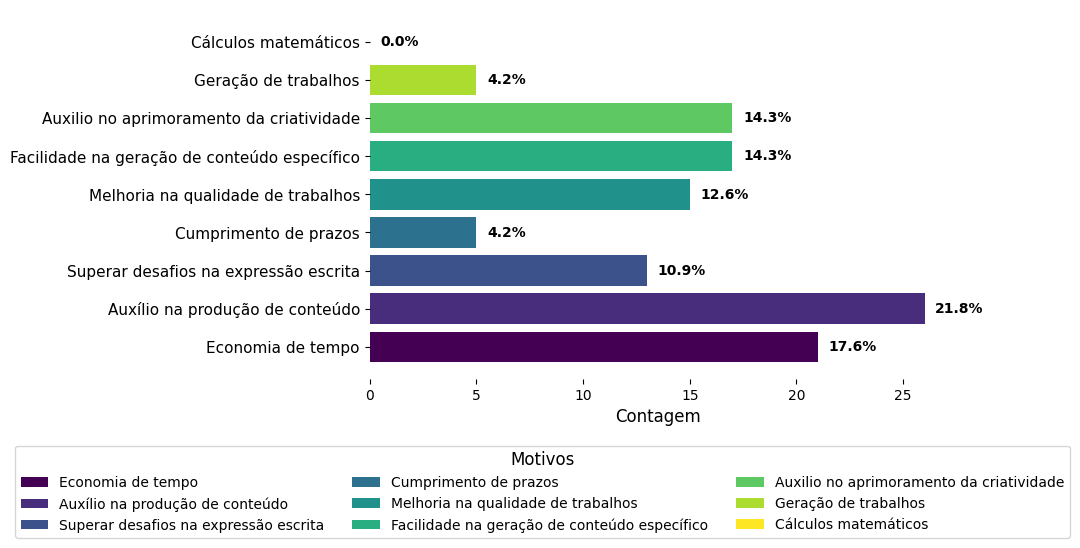


Motivos em Ciências Humanas e Sociais:
Economia de tempo: 21 (17.6%)
Auxílio na produção de conteúdo: 26 (21.8%)
Superar desafios na expressão escrita: 13 (10.9%)
Cumprimento de prazos: 5 (4.2%)
Melhoria na qualidade de trabalhos: 15 (12.6%)
Facilidade na geração de conteúdo específico: 17 (14.3%)
Auxilio no aprimoramento da criatividade: 17 (14.3%)
Geração de trabalhos: 5 (4.2%)
Cálculos matemáticos: 0 (0.0%)


C:\Users\Luise\AppData\Local\Temp\ipykernel_16992\921271228.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(motivos_atuais, fontsize=11)


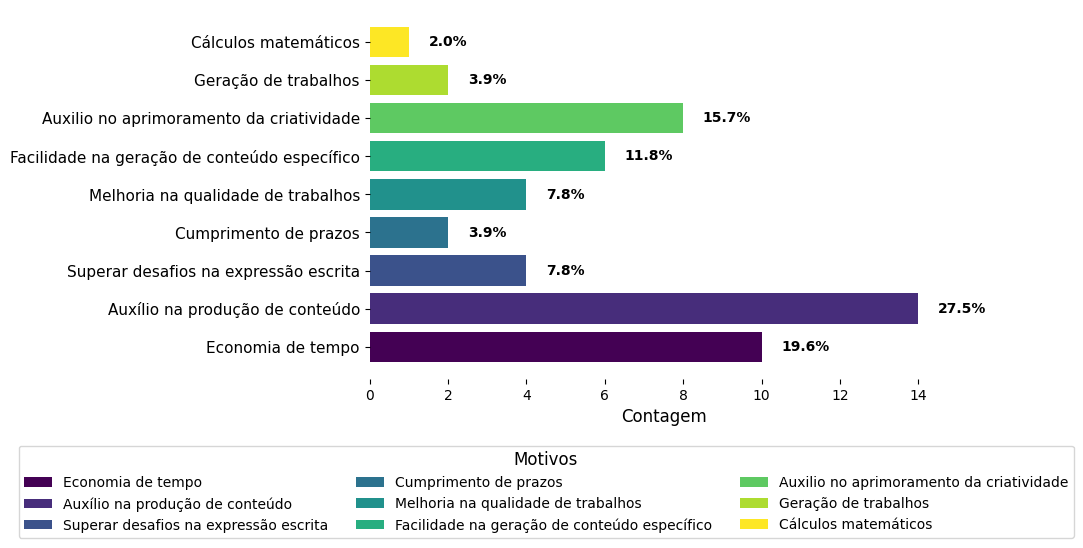


Motivos em Ciências Biológicas:
Economia de tempo: 10 (19.6%)
Auxílio na produção de conteúdo: 14 (27.5%)
Superar desafios na expressão escrita: 4 (7.8%)
Cumprimento de prazos: 2 (3.9%)
Melhoria na qualidade de trabalhos: 4 (7.8%)
Facilidade na geração de conteúdo específico: 6 (11.8%)
Auxilio no aprimoramento da criatividade: 8 (15.7%)
Geração de trabalhos: 2 (3.9%)
Cálculos matemáticos: 1 (2.0%)


C:\Users\Luise\AppData\Local\Temp\ipykernel_16992\921271228.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(motivos_atuais, fontsize=11)


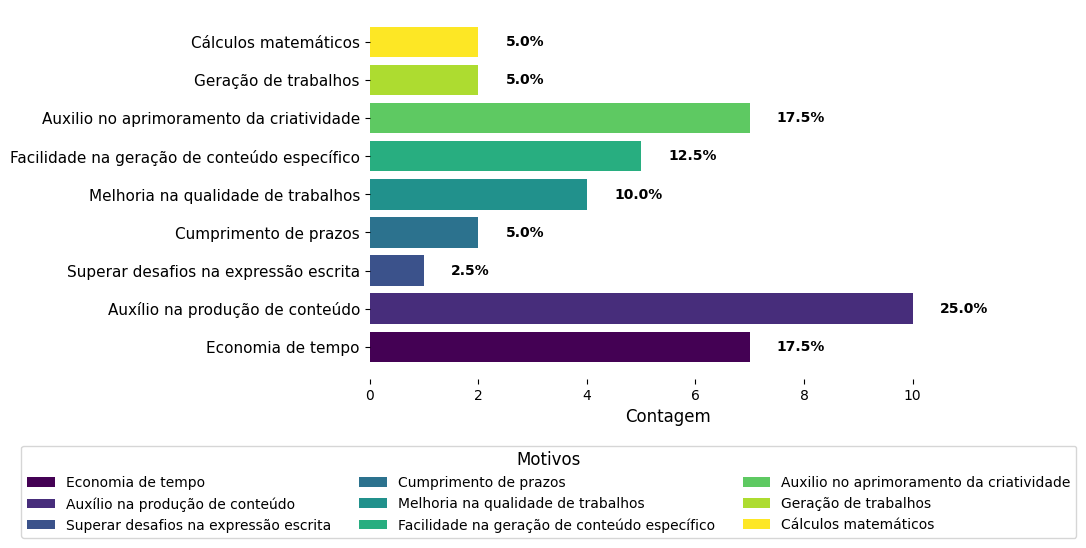


Motivos em Ciências Agrárias:
Economia de tempo: 7 (17.5%)
Auxílio na produção de conteúdo: 10 (25.0%)
Superar desafios na expressão escrita: 1 (2.5%)
Cumprimento de prazos: 2 (5.0%)
Melhoria na qualidade de trabalhos: 4 (10.0%)
Facilidade na geração de conteúdo específico: 5 (12.5%)
Auxilio no aprimoramento da criatividade: 7 (17.5%)
Geração de trabalhos: 2 (5.0%)
Cálculos matemáticos: 2 (5.0%)


In [80]:
# Lista de motivos
motivos = [
    "Economia de tempo",
    "Auxílio na produção de conteúdo",
    "Superar desafios na expressão escrita",
    "Cumprimento de prazos",
    "Melhoria na qualidade de trabalhos",
    "Facilidade na geração de conteúdo específico",
    "Auxilio no aprimoramento da criatividade",
    "Geração de trabalhos",
    "Cálculos matemáticos"
]

# Nome da coluna com os motivos
coluna_respostas = 'Qual é o principal motivo para você utilizá-la em sua área acadêmica?'
coluna_area = 'Área de Estudo Agrupada'

# Lista das áreas de estudo
areas_estudo = df[coluna_area].dropna().unique()

# Loop para criar um gráfico por área de estudo
for area in areas_estudo:
    df_area = df[df[coluna_area] == area]
    
    # Inicializar contagem de motivos
    contagem_motivos = {motivo: 0 for motivo in motivos}
    
    for resposta in df_area[coluna_respostas].dropna():
        for motivo in motivos:
            if motivo in resposta:
                contagem_motivos[motivo] += 1
    
    # Dados para o gráfico
    motivos_atuais = list(contagem_motivos.keys())
    contagens = list(contagem_motivos.values())
    total_respostas = sum(contagens)
    porcentagens = [(count / total_respostas) * 100 if total_respostas > 0 else 0 for count in contagens]
    
    # Criar gráfico horizontal
    plt.figure(figsize=(10, 6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(motivos)))
    bars = plt.barh(motivos_atuais, contagens, color=colors)
    plt.xlabel('Contagem', fontsize=12)
    # plt.title(f'Motivos para Utilização da IA na Área Acadêmica – {area}', x=0.3, fontsize=14, fontweight='bold', pad=20)
    plt.xlim(0, max(contagens) + 1)

    # Adicionar porcentagens
    for bar, percent in zip(bars, porcentagens):
        plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{percent:.1f}%', va='center', fontsize=10, fontweight='bold')
    
    # Negrito nos rótulos
    ax = plt.gca()
    ax.set_yticklabels(motivos_atuais, fontsize=11)

    # Legenda com as cores
    legend_elements = [Patch(facecolor=colors[i], label=motivos[i]) for i in range(len(motivos))]
    plt.legend(title="Motivos",
               title_fontsize=12,
               fontsize=10, 
               handles=legend_elements, 
               loc='lower center', 
               bbox_to_anchor=(0.3, -0.45), 
               ncol=3)

    # Estética
    plt.grid(False)
    plt.box(False)
    plt.tight_layout()
    plt.show()

    # Impressão dos dados
    print(f"\nMotivos em {area}:")
    for motivo, contagem, porcentagem in zip(motivos_atuais, contagens, porcentagens):
        print(f"{motivo}: {contagem} ({porcentagem:.1f}%)")


### Frequência de Uso

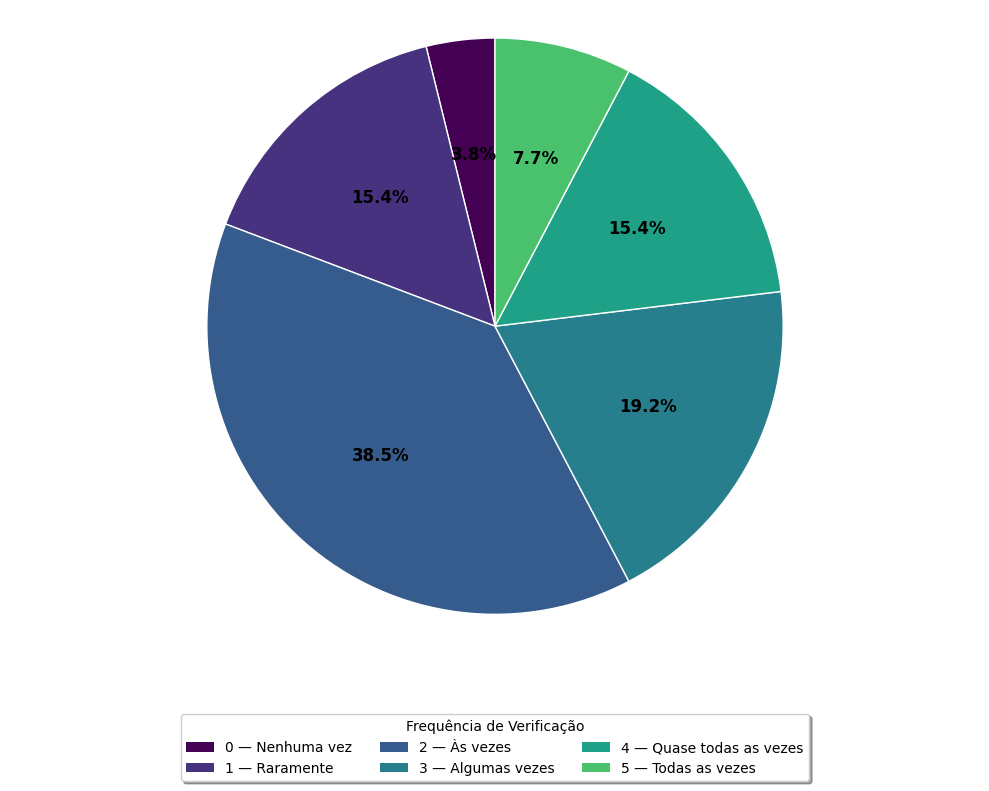


Frequência de verificação em Ciências Exatas e da Terra:
0 — Nenhuma vez: 3.8%
1 — Raramente: 15.4%
2 — Às vezes: 38.5%
3 — Algumas vezes: 19.2%
4 — Quase todas as vezes: 15.4%
5 — Todas as vezes: 7.7%


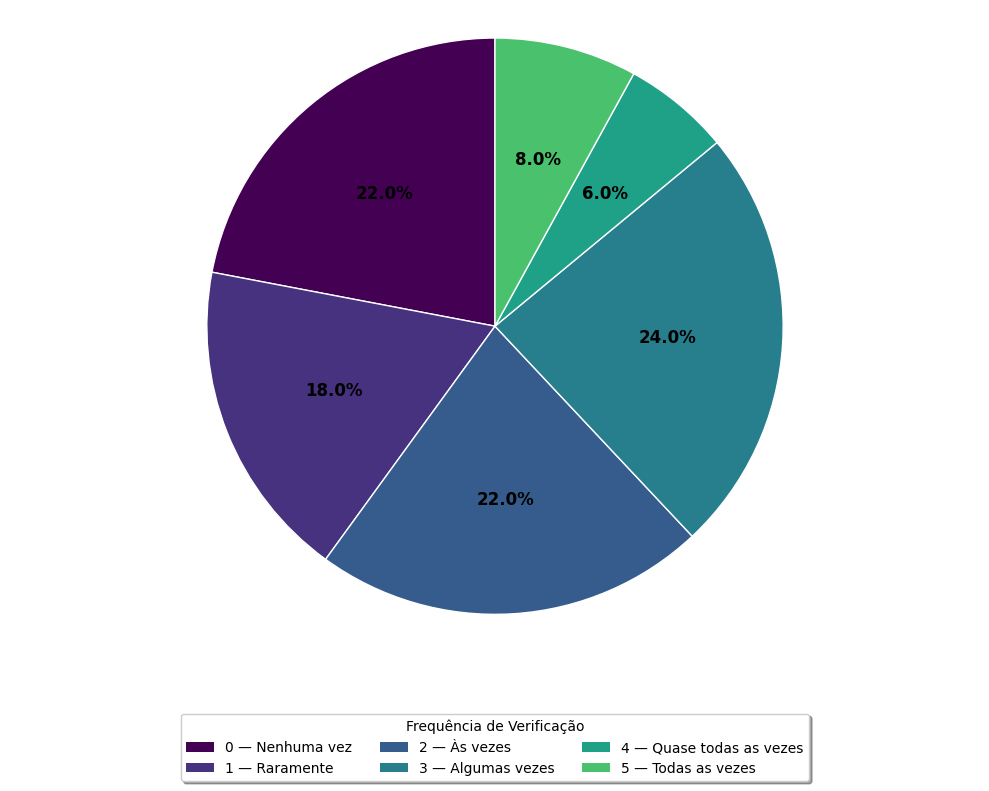


Frequência de verificação em Ciências Humanas e Sociais:
0 — Nenhuma vez: 22.0%
1 — Raramente: 18.0%
2 — Às vezes: 22.0%
3 — Algumas vezes: 24.0%
4 — Quase todas as vezes: 6.0%
5 — Todas as vezes: 8.0%


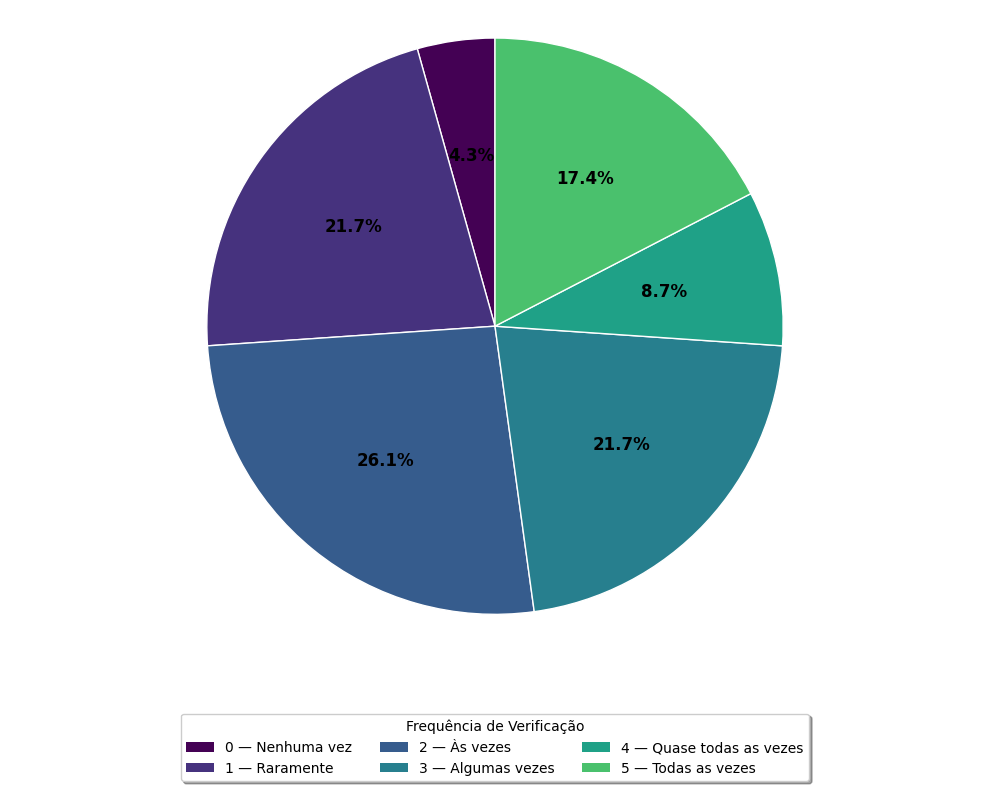


Frequência de verificação em Ciências Biológicas:
0 — Nenhuma vez: 4.3%
1 — Raramente: 21.7%
2 — Às vezes: 26.1%
3 — Algumas vezes: 21.7%
4 — Quase todas as vezes: 8.7%
5 — Todas as vezes: 17.4%


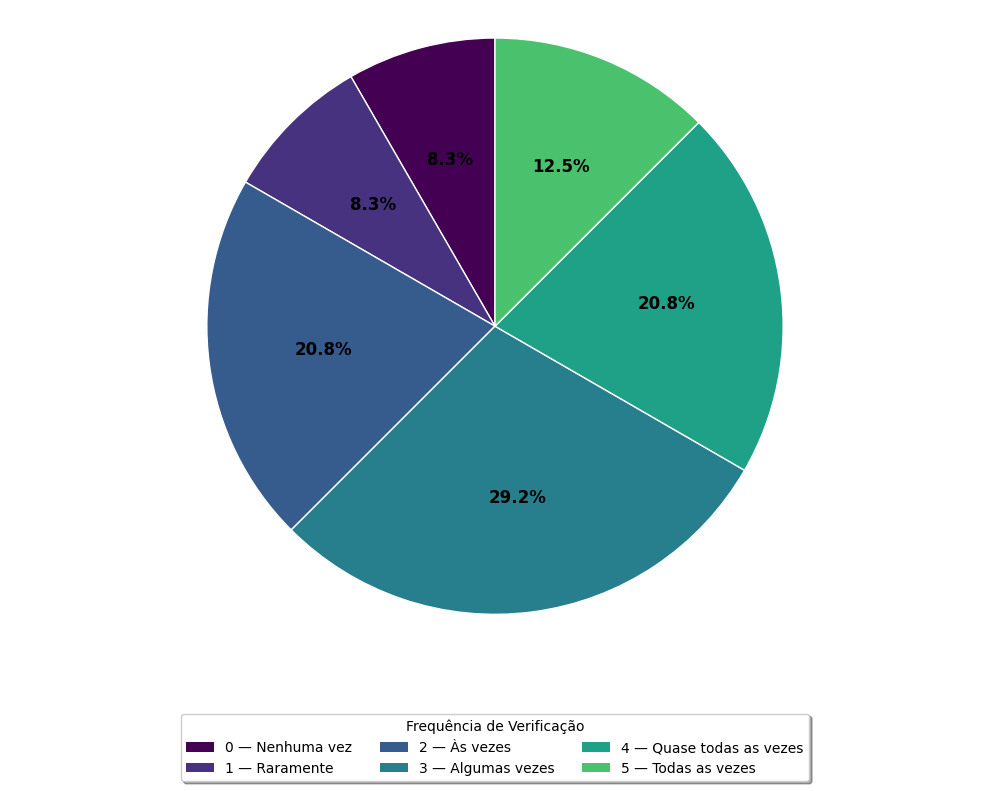


Frequência de verificação em Ciências Agrárias:
0 — Nenhuma vez: 8.3%
1 — Raramente: 8.3%
2 — Às vezes: 20.8%
3 — Algumas vezes: 29.2%
4 — Quase todas as vezes: 20.8%
5 — Todas as vezes: 12.5%


In [83]:
# Pergunta de frequência (assume-se que é a primeira que começa com 'Com que frequência')
pergunta_frequencia = df.filter(like="Com que frequência").columns[0]

# Nome da coluna de agrupamento
coluna_area = 'Área de Estudo Agrupada'
areas_estudo = df[coluna_area].dropna().unique()

# Nomenclaturas para os níveis de frequência
nomenclaturas = [
    '0 — Nenhuma vez',
    '1 — Raramente',
    '2 — Às vezes',
    '3 — Algumas vezes',
    '4 — Quase todas as vezes',
    '5 — Todas as vezes'
]

# Cores
cmap = plt.get_cmap('viridis', 8)
colors = cmap(np.arange(len(nomenclaturas)))

# Loop para gerar gráfico por área
for area in areas_estudo:
    df_area = df[df[coluna_area] == area]
    
    # Contar frequência de respostas de 0 a 5 e normalizar para porcentagem
    contagem_respostas = df_area[pergunta_frequencia].value_counts(normalize=True).sort_index() * 100
    respostas = [contagem_respostas.get(i, 0) for i in range(6)]  # Garante todas as categorias de 0 a 5
    
    # Criar gráfico de pizza
    plt.figure(figsize=(10, 8))
    wedges, texts, autotexts = plt.pie(respostas, labels=None, autopct='%1.1f%%',
                                       startangle=90, colors=colors,
                                       wedgeprops={'edgecolor': 'white'})
    
    # plt.title(f'Frequência de Verificação das Informações – {area}', fontsize=16, fontweight='bold')
    plt.axis('equal')
    
    for autotext in autotexts: # Ajustar o texto da porcentagem
        autotext.set_fontsize(12)
        autotext.set_color('black')
        autotext.set_fontweight('bold')
    
    legend_elements = [Patch(facecolor=colors[i], label=nomenclaturas[i])
                       for i in range(len(nomenclaturas))]
    
    plt.legend(handles=legend_elements, title='Frequência de Verificação', loc='upper center',
               bbox_to_anchor=(0.5, -0.1), ncol=3, fancybox=True, shadow=True, fontsize=10)
    
    plt.tight_layout()
    plt.box(False)
    plt.grid(False)
    plt.show()
    
    # Imprimir dados para referência
    print(f"\nFrequência de verificação em {area}:")
    for i, percentual in enumerate(respostas):
        print(f"{nomenclaturas[i]}: {percentual:.1f}%")

### Ferramentas de IAG utilizadas

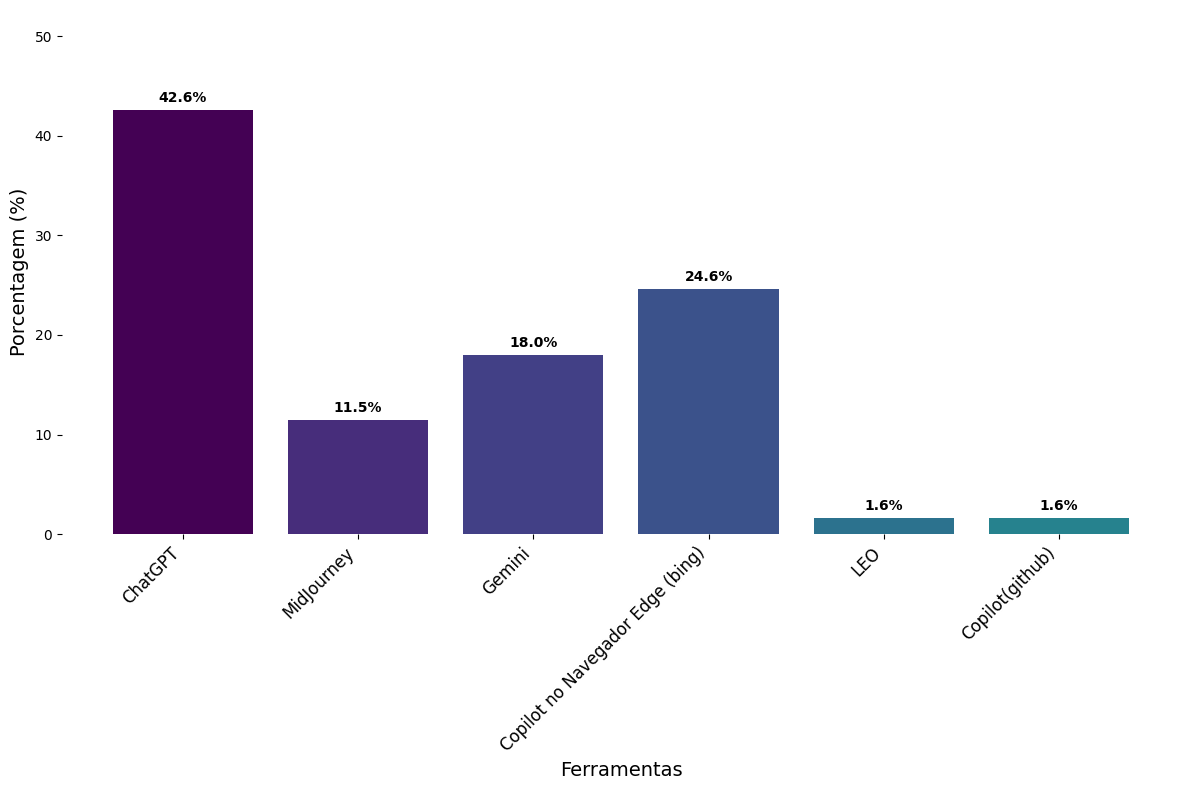


Contagem de ferramentas para Ciências Exatas e da Terra:
{'ChatGPT': 26, 'BERT': 0, 'MidJourney': 7, 'Gemini': 11, 'Copilot no Navegador Edge (bing)': 15, 'Nenhuma': 0, 'LEO': 1, 'Copilot(github)': 1, 'Youchat.com': 0, 'Perplexity': 0, 'SeaArt': 0, 'AssemblyAI': 0, 'Adobe Express': 0, 'AI Voice Generator': 0, 'Stockming AI': 0, 'Gamma': 0, 'Seowriting.ai': 0}


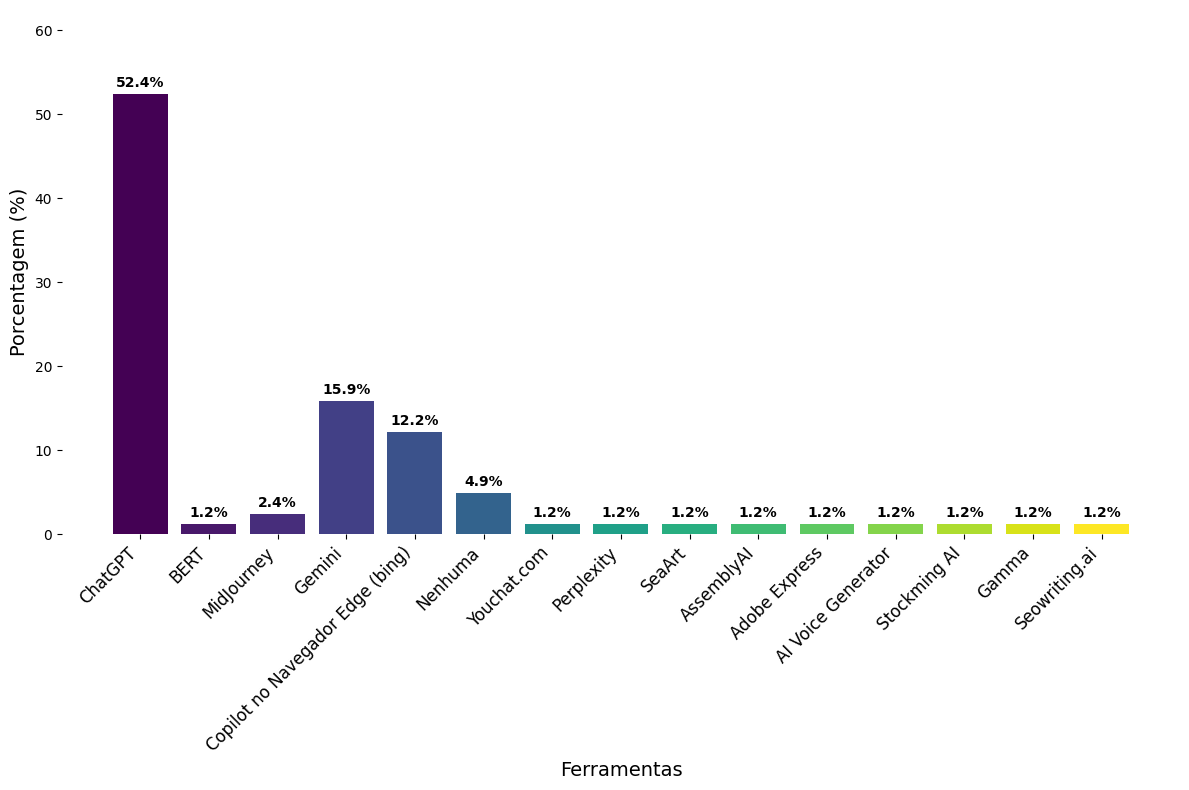


Contagem de ferramentas para Ciências Humanas e Sociais:
{'ChatGPT': 43, 'BERT': 1, 'MidJourney': 2, 'Gemini': 13, 'Copilot no Navegador Edge (bing)': 10, 'Nenhuma': 4, 'LEO': 0, 'Copilot(github)': 0, 'Youchat.com': 1, 'Perplexity': 1, 'SeaArt': 1, 'AssemblyAI': 1, 'Adobe Express': 1, 'AI Voice Generator': 1, 'Stockming AI': 1, 'Gamma': 1, 'Seowriting.ai': 1}


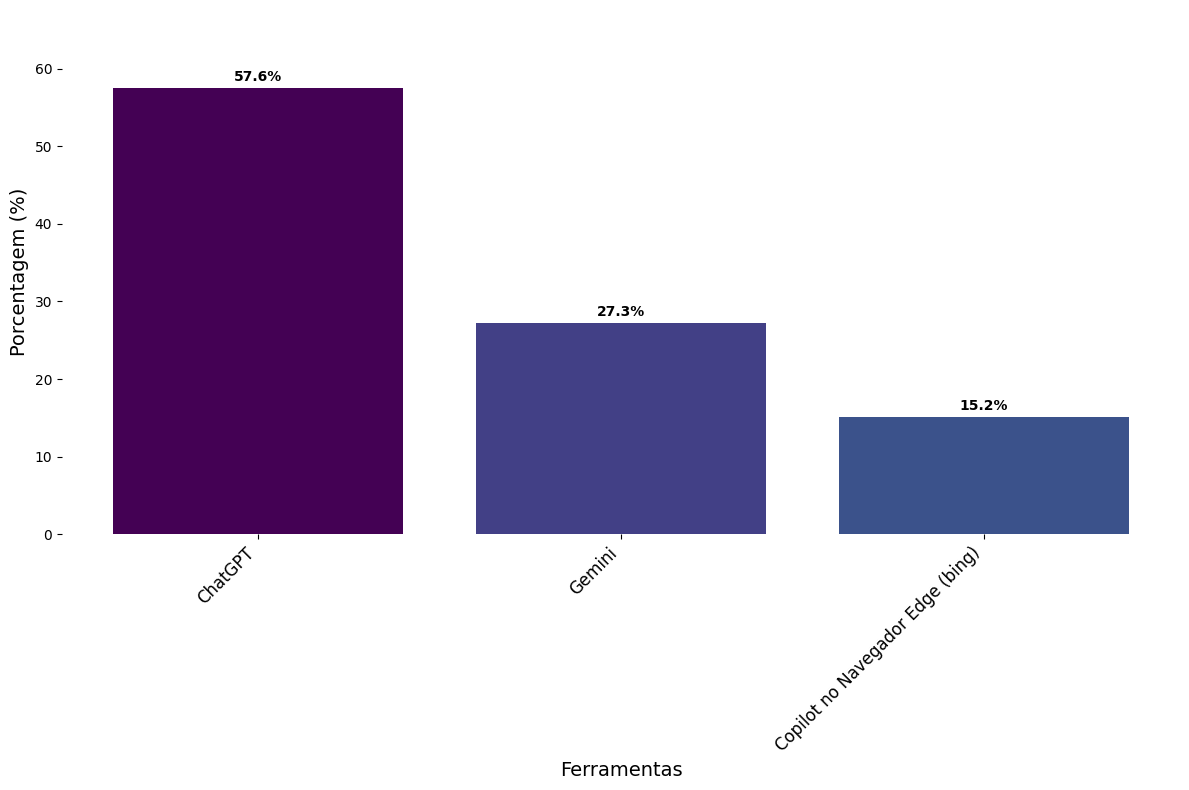


Contagem de ferramentas para Ciências Biológicas:
{'ChatGPT': 19, 'BERT': 0, 'MidJourney': 0, 'Gemini': 9, 'Copilot no Navegador Edge (bing)': 5, 'Nenhuma': 0, 'LEO': 0, 'Copilot(github)': 0, 'Youchat.com': 0, 'Perplexity': 0, 'SeaArt': 0, 'AssemblyAI': 0, 'Adobe Express': 0, 'AI Voice Generator': 0, 'Stockming AI': 0, 'Gamma': 0, 'Seowriting.ai': 0}


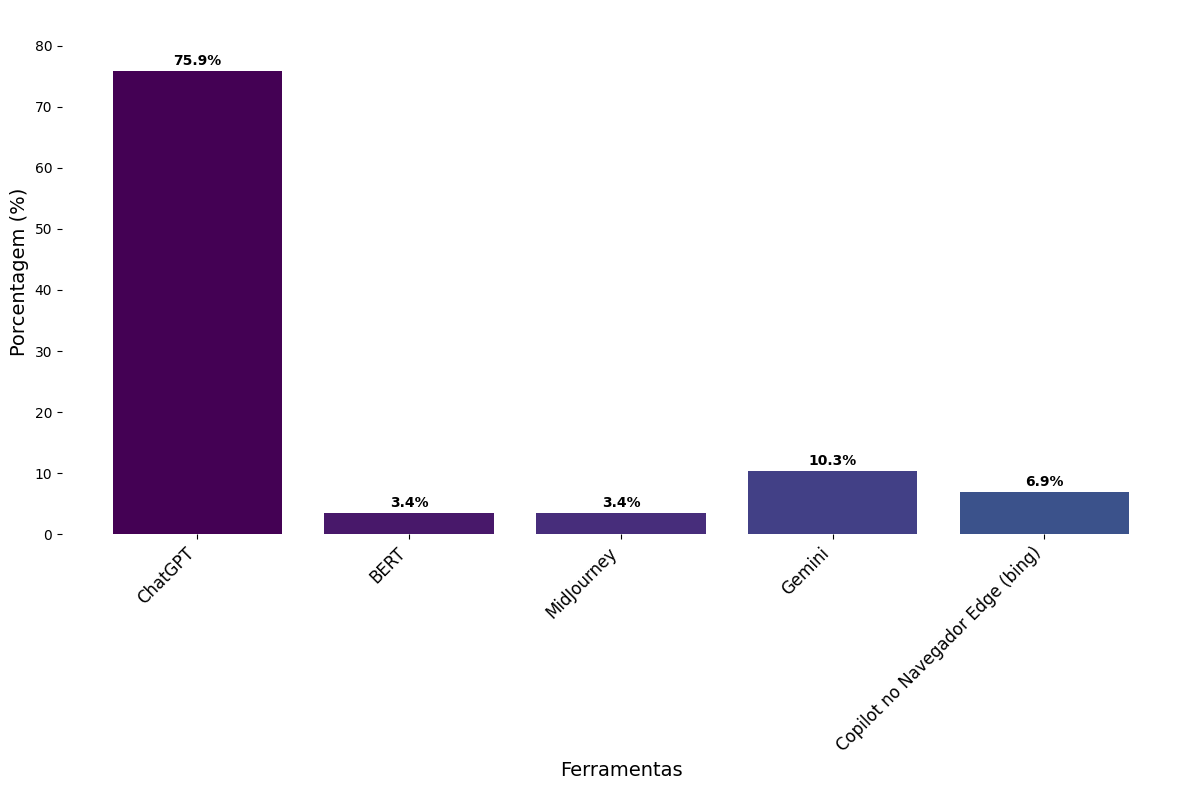


Contagem de ferramentas para Ciências Agrárias:
{'ChatGPT': 22, 'BERT': 1, 'MidJourney': 1, 'Gemini': 3, 'Copilot no Navegador Edge (bing)': 2, 'Nenhuma': 0, 'LEO': 0, 'Copilot(github)': 0, 'Youchat.com': 0, 'Perplexity': 0, 'SeaArt': 0, 'AssemblyAI': 0, 'Adobe Express': 0, 'AI Voice Generator': 0, 'Stockming AI': 0, 'Gamma': 0, 'Seowriting.ai': 0}


In [102]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Lista de ferramentas (estabelecida)
ferramentas = [
    "ChatGPT",
    "BERT",
    "MidJourney",
    "Gemini",
    "Copilot no Navegador Edge (bing)",
    "Nenhuma",
    "LEO",
    "Copilot(github)",
    "Youchat.com",
    "Perplexity",
    "SeaArt",
    "AssemblyAI",
    "Adobe Express",
    "AI Voice Generator",
    "Stockming AI",
    "Gamma",
    "Seowriting.ai"
]

# Função para normalizar strings: remove espaços extras e converte para minúsculas
def normalizar_ferramenta(ferramenta_str):
    return ferramenta_str.strip().lower()

# Definir as colunas de interesse: a resposta e a área de estudo agrupada
coluna_ferramentas = 'Cite quais as ferramentas de IA generativa você utiliza. (Marque todas que se aplicam)'
coluna_area = 'Área de Estudo Agrupada'

# Obter as áreas de estudo, excluindo valores nulos
areas_estudo = df[coluna_area].dropna().unique()

# Criar uma paleta de cores global para todas as ferramentas, garantindo que cada ferramenta tenha a mesma cor
global_colors_array = plt.cm.viridis(np.linspace(0, 1, len(ferramentas)))
global_colors = {ferramenta: color for ferramenta, color in zip(ferramentas, global_colors_array)}

# Loop para cada área de estudo; para cada uma, gerar um gráfico de barras verticais
for area in areas_estudo:
    # Filtrar os dados para a área
    df_area = df[df[coluna_area] == area]
    
    # Inicializar contagem de cada ferramenta para a área
    contagem_ferramentas = {ferramenta: 0 for ferramenta in ferramentas}
    
    # Processar as respostas (assumindo que as respostas são separadas por vírgula)
    for resposta in df_area[coluna_ferramentas].dropna():
        ferramentas_resposta = [normalizar_ferramenta(f) for f in resposta.split(',')]
        for ferramenta in ferramentas_resposta:
            # Se a resposta indicar "nenhuma" ou variações similares, agrupar em "Nenhuma"
            if any(termo in ferramenta for termo in ["nenhuma", "não uso", "não utilizei", "não utilizo"]):
                contagem_ferramentas["Nenhuma"] += 1
            else:
                for key in contagem_ferramentas.keys():
                    if normalizar_ferramenta(key) == ferramenta:
                        contagem_ferramentas[key] += 1
                        break
    
    # Preparar os dados para o gráfico, mantendo a ordem definida em "ferramentas"
    contagens = [contagem_ferramentas[ferramenta] for ferramenta in ferramentas]
    total_respostas = sum(contagens)
    # Calcular as porcentagens – se total_respostas for 0, todas serão 0
    porcentagens = [(count / total_respostas) * 100 if total_respostas > 0 else 0 for count in contagens]
    
    # Filtrar os dados: manter apenas as ferramentas com porcentagem maior que 0
    ferramentas_filtradas = [f for f, pct in zip(ferramentas, porcentagens) if pct > 0]
    porcentagens_filtradas = [pct for pct in porcentagens if pct > 0]
    cores_filtradas = [global_colors[f] for f, pct in zip(ferramentas, porcentagens) if pct > 0]
    
    # Verifica se há algum dado para plotar
    if not ferramentas_filtradas:
        print(f"\nNenhuma ferramenta reportada com porcentagem > 0 para {area}.")
        continue
    
    # Criar gráfico de barras verticais
    plt.figure(figsize=(12, 8))
    x = np.arange(len(ferramentas_filtradas))
    bars = plt.bar(x, porcentagens_filtradas, color=cores_filtradas)
    plt.xlabel('Ferramentas', fontsize=14)
    plt.ylabel('Porcentagem (%)', fontsize=14)
    # plt.title(f'Ferramentas de IA Generativa – {area}', fontsize=16)
    
    # Configurar os rótulos do eixo X para mostrar os nomes das ferramentas filtradas
    plt.xticks(x, ferramentas_filtradas, rotation=45, ha="right", fontsize=12)
    
    # Adicionar rótulos acima das barras (apenas para barras com porcentagem > 0; aqui já foram filtradas)
    for bar, pct in zip(bars, porcentagens_filtradas):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{pct:.1f}%', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.ylim(0, max(porcentagens_filtradas) + 10)
    plt.grid(False)
    plt.box(False)
    plt.tight_layout()
    plt.show()
    
    # Imprimir a contagem para referência
    print(f"\nContagem de ferramentas para {area}:")
    print(contagem_ferramentas)


### Prazos Apertados

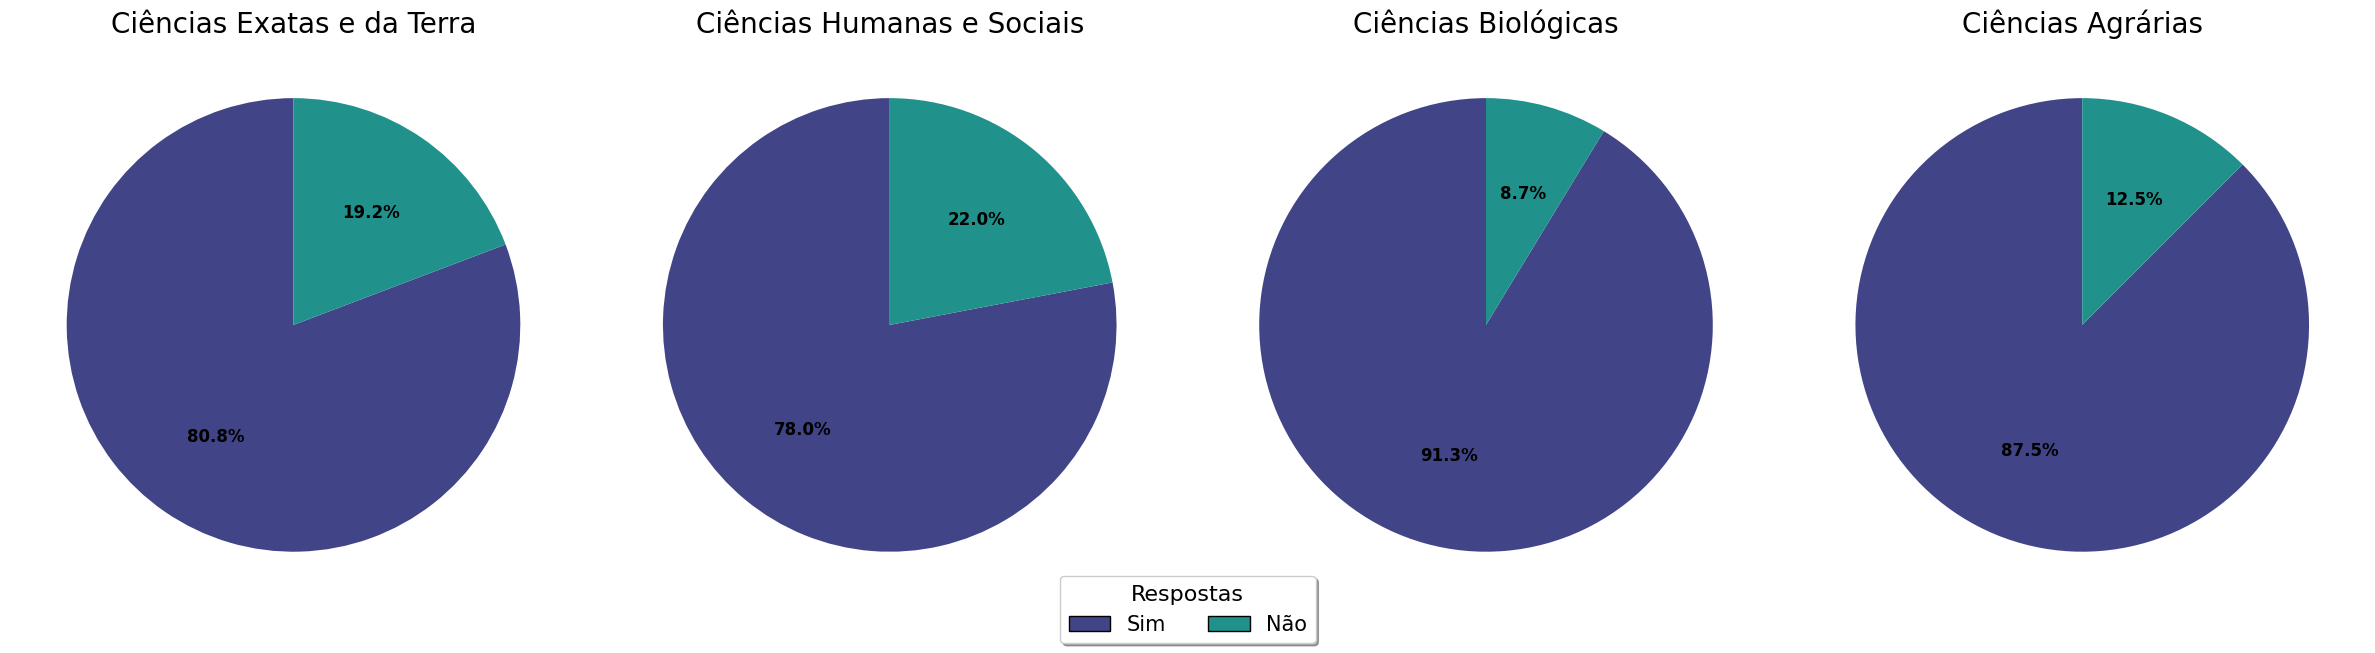

In [115]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

coluna_prazos_apertados = 'Em situações de prazos apertados, a IA generativa é uma escolha para atender a essas demandas?'
coluna_area = 'Área de Estudo Agrupada'

cores = plt.cm.viridis([0.2, 0.5])
areas_estudo = df[coluna_area].dropna().unique()

fig, axes = plt.subplots(1, len(areas_estudo), figsize=(6 * len(areas_estudo), 6))

# Se tiver só 1 gráfico, axes não é uma lista
if len(areas_estudo) == 1:
    axes = [axes]

for ax, area in zip(axes, areas_estudo):
    df_area = df[df[coluna_area] == area]
    respostas_prazos = df_area[coluna_prazos_apertados].value_counts(normalize=True) * 100

    if respostas_prazos.empty:
        ax.axis('off')
        continue

    wedges, texts, autotexts = ax.pie(
        respostas_prazos, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=cores[:len(respostas_prazos)],
        textprops={'fontsize': 12, 'fontweight': 'bold'},
    )

    ax.set_title(f'{area}', fontsize=20)

# Criar legenda global
legend_elements = [
    Patch(facecolor=cores[i], label=respostas_prazos.index[i], edgecolor='black') 
    for i in range(len(respostas_prazos))
]
fig.legend(
    handles=legend_elements, 
    title='Respostas', 
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.05), 
    ncol=2, 
    fancybox=True, 
    shadow=True, 
    fontsize=15,
    title_fontsize=16
)

plt.tight_layout()
plt.show()


### Interação com IAG (Categorização se é bom, ruim ou neutra)

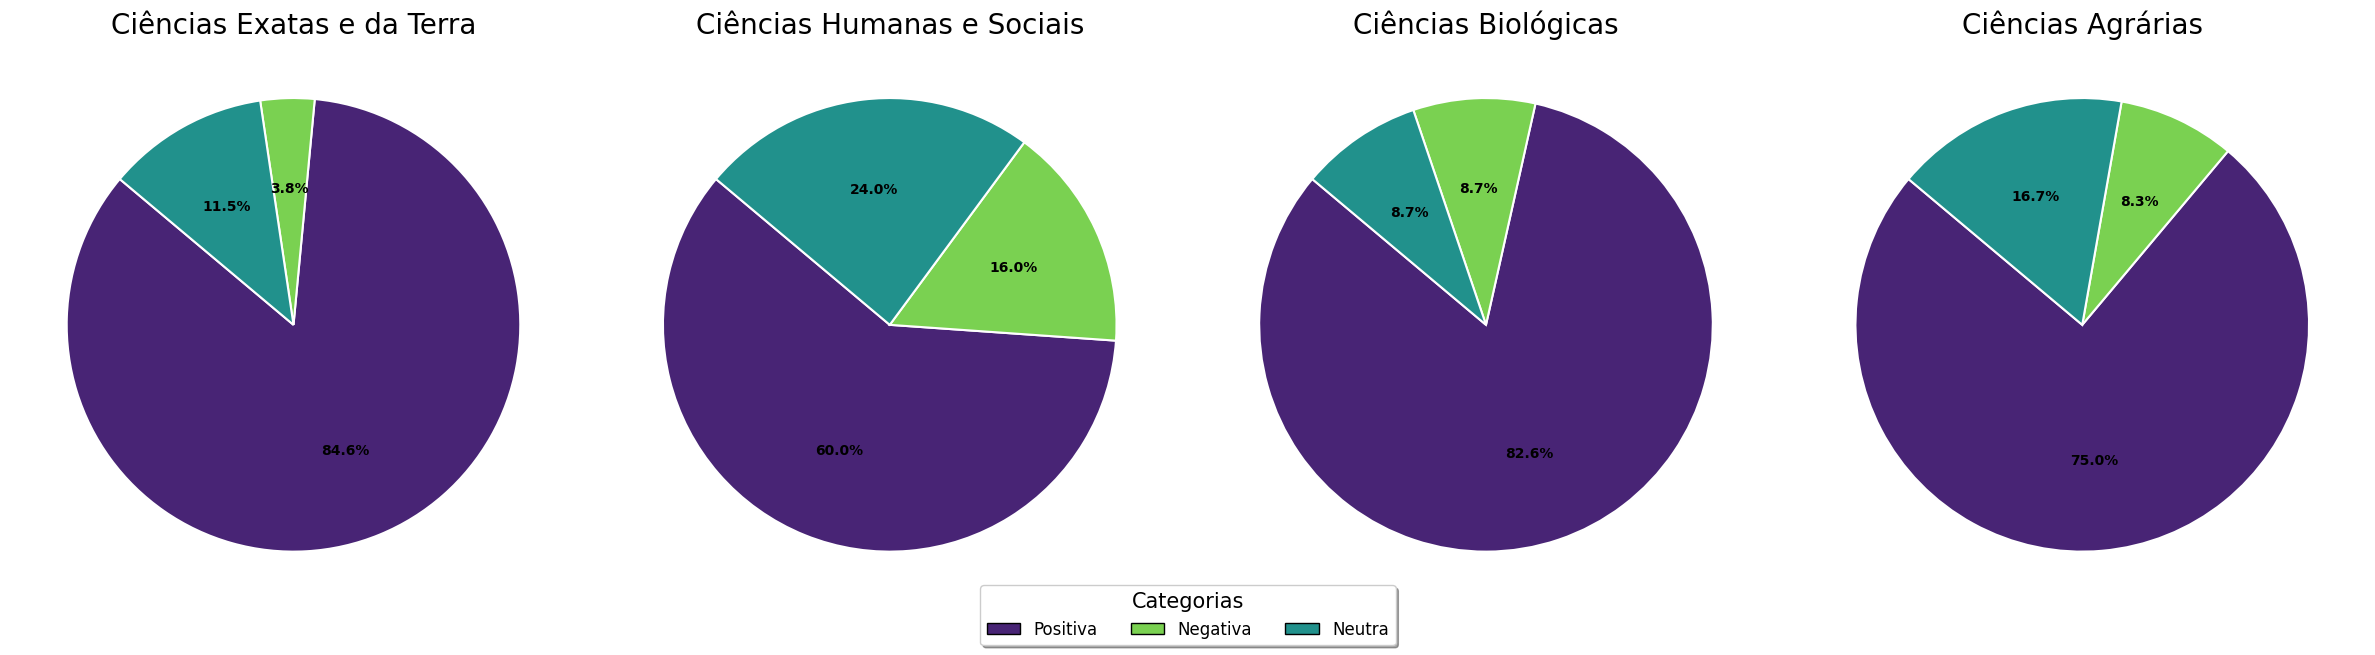

In [119]:
# Normaliza as respostas para facilitar a categorização
df['respostas'] = df['Você considera a interação IA e acadêmicos positiva, negativa ou neutra? Por quê?'].str.lower().str.strip()
coluna_area = 'Área de Estudo Agrupada'

# Define cores fixas para consistência entre gráficos
cores = {
    'positiva': plt.cm.viridis(0.1),
    'negativa': plt.cm.viridis(0.8),
    'neutra': plt.cm.viridis(0.5)
}

categorias = ['positiva', 'negativa', 'neutra']
areas = df[coluna_area].dropna().unique()

# Criação da figura com 1 linha e 4 colunas
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Se tiver menos de 4 áreas, preencher com gráficos vazios
for i in range(len(axes)):
    if i >= len(areas):
        axes[i].axis('off')

# Função auxiliar para categorizar
def classificar_resposta(texto):
    if pd.isna(texto): return 'neutra'
    texto = texto.lower()
    if any(p in texto for p in ['positiva', 'ajuda', 'útil', 'importante', 'apoio', 'facilitador', 'melhor', 'esclarece', 'auxilia']):
        return 'positiva'
    elif any(n in texto for n in ['negativa', 'prejudica', 'perde', 'diminui', 'limita', 'descreve', 'desinteresse', 'burrice', 'cola', 'não', 'mau', 'difícil']):
        return 'negativa'
    elif any(n in texto for n in ['neutra', 'depende', 'não sei', 'sem opinião', 'não utilizo']):
        return 'neutra'
    else:
        return 'neutra'

# Aplica a classificação
df['classificacao'] = df['respostas'].apply(classificar_resposta)

# Plot por área
for i, area in enumerate(areas):
    df_area = df[df[coluna_area] == area]
    contagem = df_area['classificacao'].value_counts()
    porcentagens = {key: (contagem.get(key, 0) / len(df_area)) * 100 for key in categorias}
    sizes = list(contagem.get(cat, 0) for cat in categorias)
    
    ax = axes[i]
    wedges, texts, autotexts = ax.pie(
        sizes, 
        labels=None,
        colors=[cores[cat] for cat in categorias],
        autopct='%1.1f%%',
        startangle=140,
        textprops=dict(color='white'),
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )

    ax.set_title(f'{area}', fontsize=20)

    for autotext in autotexts:
        autotext.set_fontsize(10)
        autotext.set_color('black')
        autotext.set_fontweight('bold')

# Legenda global
legend_elements = [Patch(facecolor=cores[cat], label=cat.capitalize(), edgecolor='black') for cat in categorias]
fig.legend(
    handles=legend_elements,
    title='Categorias',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
    fancybox=True,
    shadow=True,
    fontsize=12,
    title_fontsize=15
)

plt.tight_layout()
plt.show()


### Familiaridade com IAG

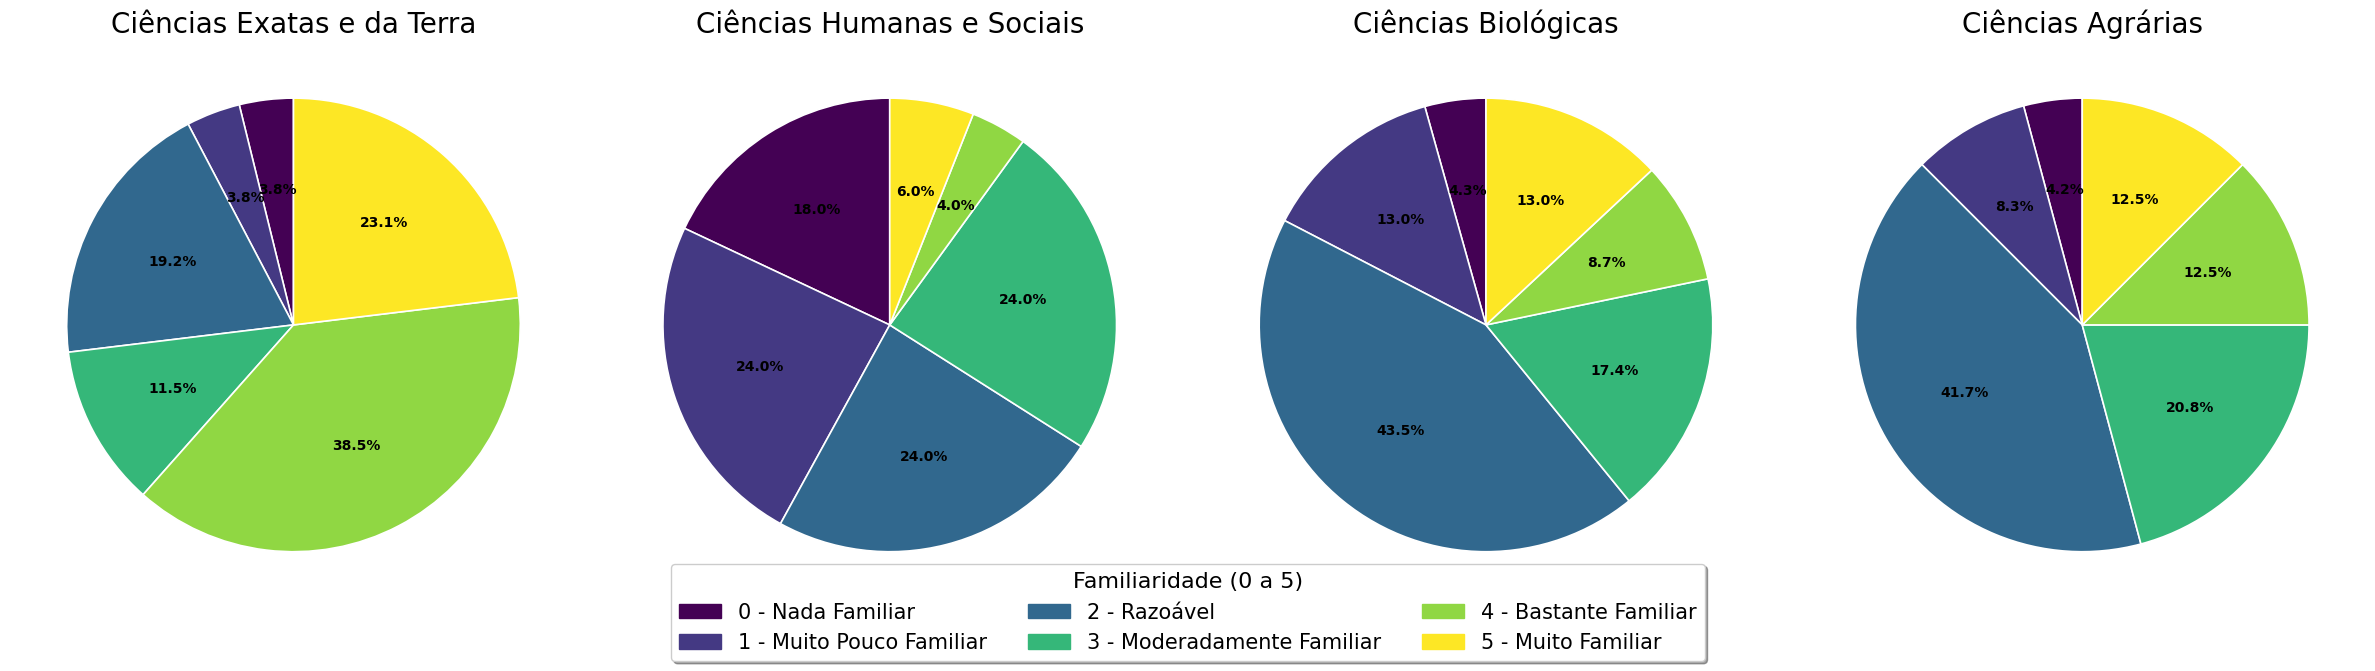

In [127]:
# Pergunta sobre familiaridade
pergunta_familiaridade = "Quão familiar você se considera com as capacidades da IA generativa? (0 para pouco e 5 para muito)"
coluna_area = 'Área de Estudo Agrupada'

# Nomenclatura das respostas
nomenclaturas = ['0 - Nada Familiar', '1 - Muito Pouco Familiar', '2 - Razoável', 
                 '3 - Moderadamente Familiar', '4 - Bastante Familiar', '5 - Muito Familiar']

# Cores com colormap viridis
cmap = plt.get_cmap('viridis', 7)
cores = cmap(np.linspace(0, 1, 6))

# Áreas únicas
areas = df[coluna_area].dropna().unique()

# Criar subplots lado a lado
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Loop pelas áreas
for i, area in enumerate(areas):
    if i >= 4:
        break  # Apenas até 4 áreas

    ax = axes[i]
    df_area = df[df[coluna_area] == area]

    # Contagem de respostas de 0 a 5, normalizada
    contagem_respostas = df_area[pergunta_familiaridade].value_counts(normalize=True).sort_index() * 100
    respostas = [contagem_respostas.get(i, 0) for i in range(6)]

    # Gráfico de pizza
    wedges, texts, autotexts = ax.pie(respostas, labels=None, colors=cores, autopct='%1.1f%%',
                                      startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
                                      textprops=dict(color="black", fontweight='bold'))

    ax.set_title(f'{area}', fontsize=20)  # Sem negrito

# Legenda única para todos
legend_elements = [Patch(color=cores[i], label=nomenclaturas[i]) for i in range(6)]
fig.legend(handles=legend_elements, title='Familiaridade (0 a 5)', loc='lower center',
           bbox_to_anchor=(0.5, -0.08), ncol=3, fancybox=True, shadow=True, fontsize=15, title_fontsize=16)

plt.tight_layout()
plt.show()


### Comprometimento da Autenticidade ao Utilizar IA Generativa

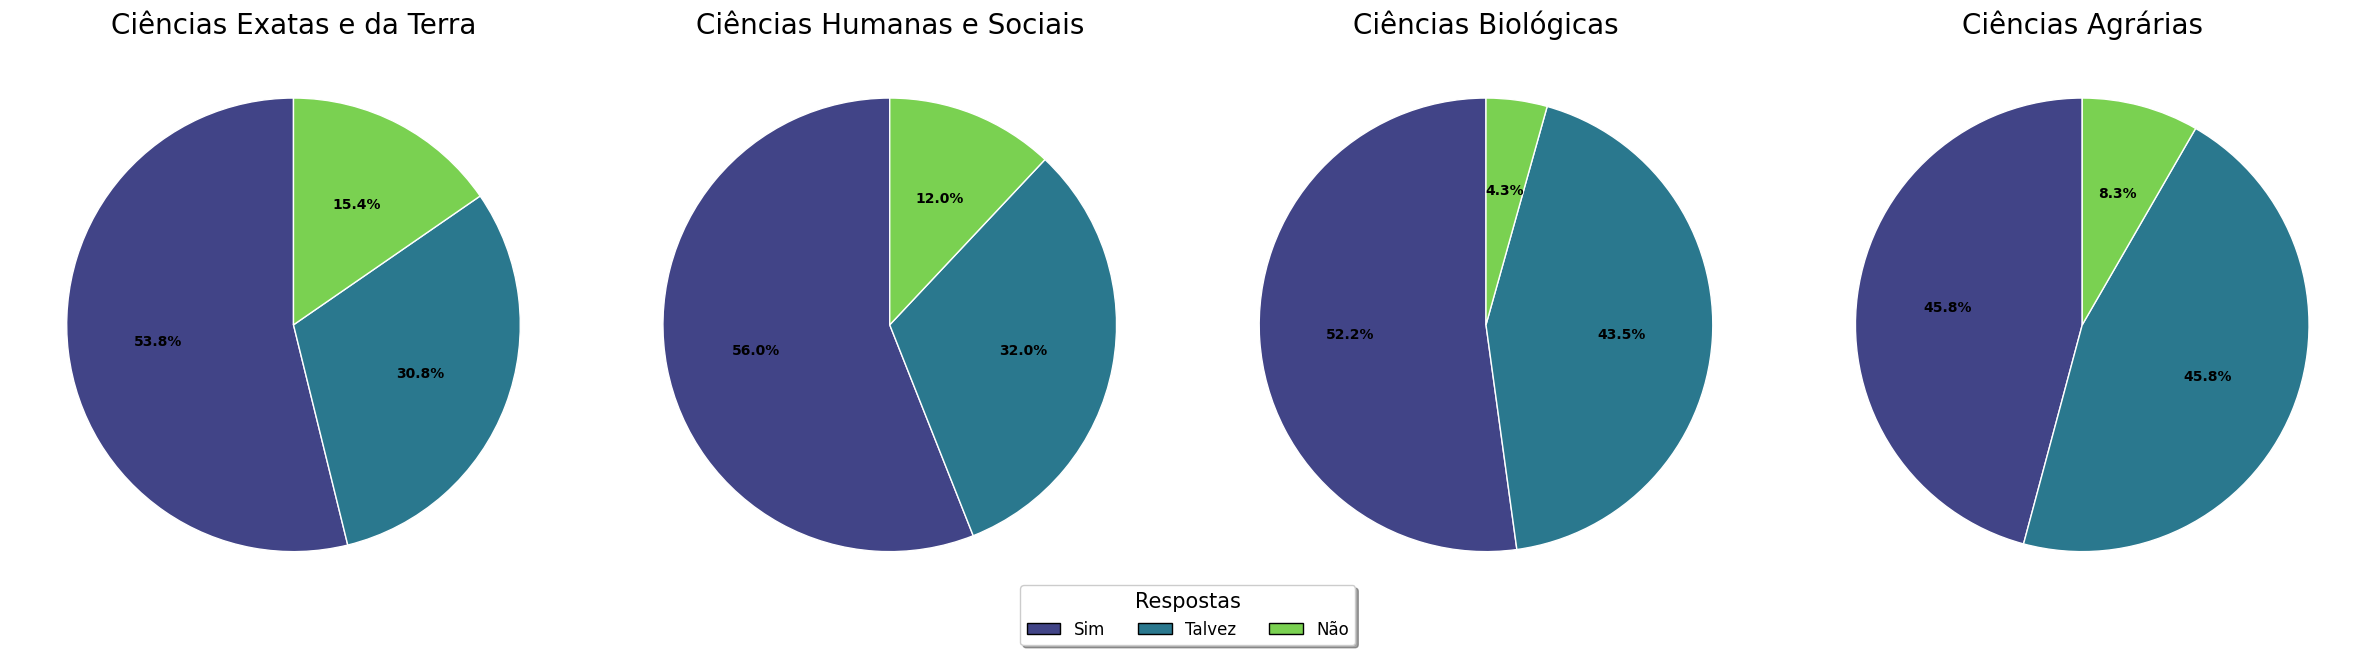

In [129]:
# Coluna com a pergunta sobre autenticidade
coluna_autenticidade = 'Você acredita que o uso da IA generativa pode comprometer a autenticidade do seu trabalho acadêmico?'
coluna_area = 'Área de Estudo Agrupada'

# Paleta de cores
cores = plt.cm.viridis([0.2, 0.4, 0.8])  # Ajustável conforme o número de categorias

# Áreas únicas
areas = df[coluna_area].dropna().unique()

# Criar subplots
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Loop pelas áreas
for i, area in enumerate(areas):
    if i >= 4:
        break  # Limita a 4 áreas

    ax = axes[i]
    df_area = df[df[coluna_area] == area]

    # Contagem das respostas
    contagem_respostas = df_area[coluna_autenticidade].value_counts()
    labels = contagem_respostas.index.tolist()
    sizes = contagem_respostas.values.tolist()

    # Gráfico de pizza
    wedges, texts, autotexts = ax.pie(sizes, labels=None, colors=cores[:len(sizes)], autopct='%1.1f%%',
                                      wedgeprops=dict(edgecolor='white'), startangle=90,
                                      textprops=dict(color='black', fontweight='bold'))

    ax.set_title(f'{area}', fontsize=20)  # Sem negrito

# Legenda única
legend_elements = [Patch(facecolor=cores[i], edgecolor='black', label=labels[i]) for i in range(len(labels))]
fig.legend(handles=legend_elements, title="Respostas", loc="lower center",
           bbox_to_anchor=(0.5, -0.05), ncol=3, fancybox=True, shadow=True, fontsize=12, title_fontsize=15)

plt.tight_layout()
plt.show()


### Pergunta Aberta sobre os motivos de IAG ser eficiente em atividades acadêmicas

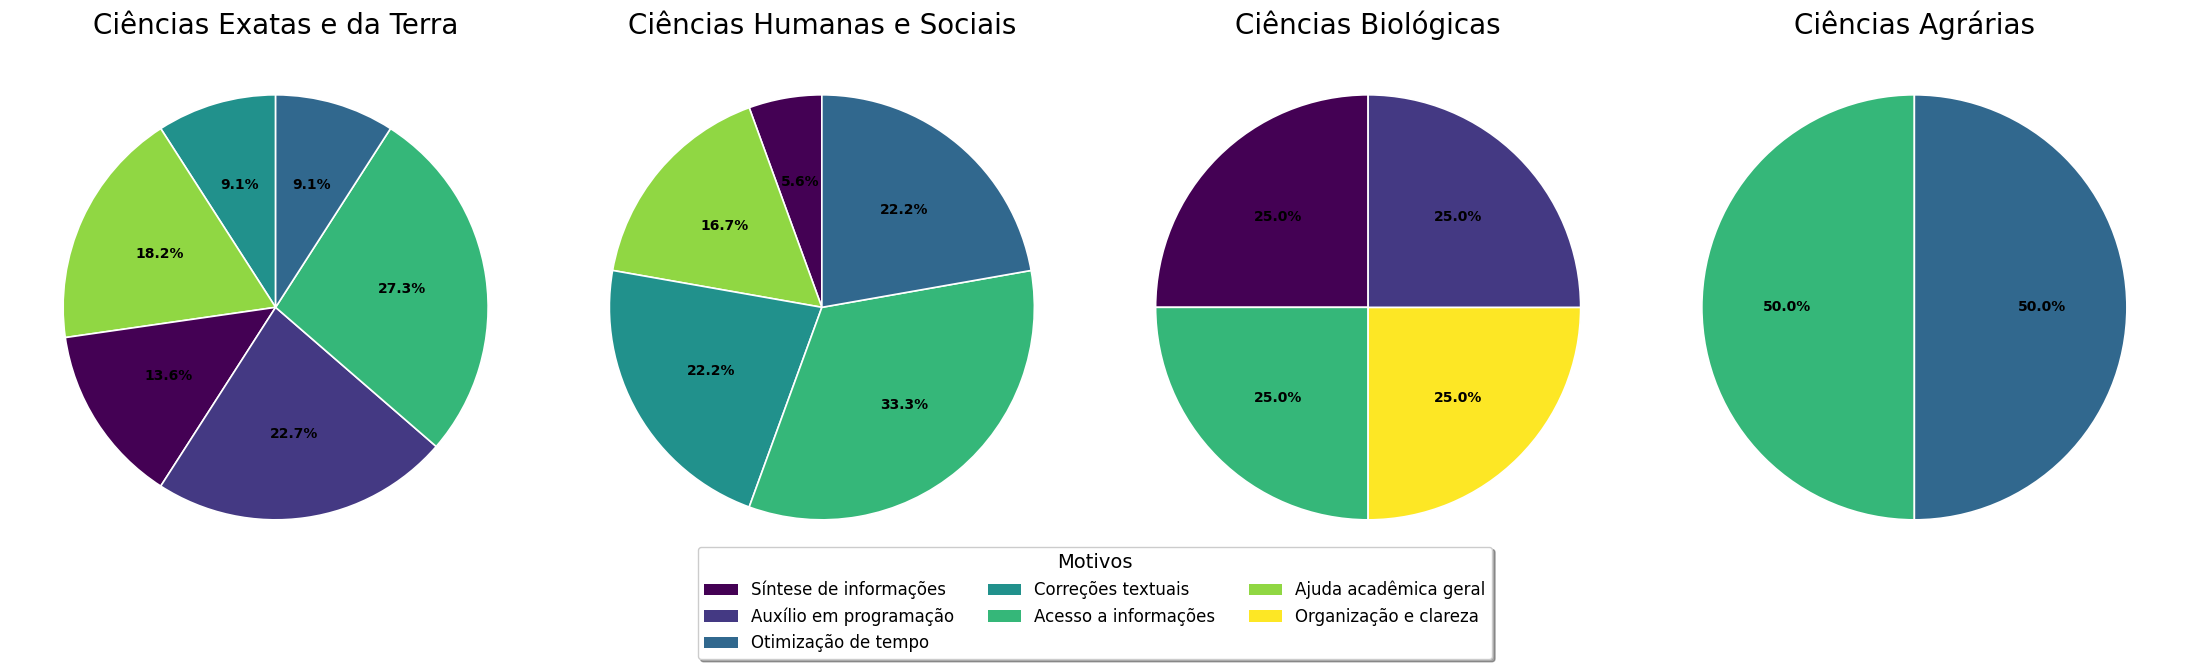

In [133]:
from collections import Counter

# Pergunta de interesse
coluna_resposta = 'Se sim, por que você considera a IA generativa eficiente em suas atividades acadêmicas?'
coluna_area = 'Área de Estudo Agrupada'

# Palavras-chave
palavras_chave = {
    'Síntese de informações': ['sintetizar', 'sintetiza', 'resumo', 'resumir', 'agrega'],
    'Auxílio em programação': ['código', 'programação', 'codificação', 'debug', 'bugs', 'copilot'],
    'Otimização de tempo': ['tempo', 'agilidade', 'produtividade'],
    'Correções textuais': ['texto', 'gramatical', 'correção', 'escrita'],
    'Acesso a informações': ['informações', 'conteúdo', 'dados', 'conhecimento'],
    'Ajuda acadêmica geral': ['acadêmico', 'estudo', 'aprendizado', 'pesquisa'],
    'Organização e clareza': ['organizar', 'estruturar', 'clareza', 'estruturado'],
}

# Função para categorizar respostas
def categorizar_respostas(respostas, palavras_chave):
    categorias_contagem = Counter()
    for resposta in respostas:
        for categoria, palavras in palavras_chave.items():
            if any(palavra in resposta.lower() for palavra in palavras):
                categorias_contagem[categoria] += 1
    return categorias_contagem

# Obter áreas únicas
areas_estudo = df[coluna_area].dropna().unique()

# Criar subplots
fig, axes = plt.subplots(1, len(areas_estudo), figsize=(22, 6))

# Paleta de cores
cores_base = plt.cm.viridis(np.linspace(0, 1, len(palavras_chave)))

for ax, area in zip(axes, areas_estudo):
    # Filtrar dados
    respostas_area = df[df[coluna_area] == area][coluna_resposta].dropna()
    
    # Categorizar
    contagem_area = categorizar_respostas(respostas_area, palavras_chave)

    if not contagem_area:
        ax.axis('off')
        continue

    # Preparar dados para plot
    categorias = list(contagem_area.keys())
    valores = list(contagem_area.values())
    cores = [cores_base[list(palavras_chave.keys()).index(cat)] for cat in categorias]

    # Gráfico de pizza
    wedges, texts, autotexts = ax.pie(
        valores,
        labels=None,
        autopct='%1.1f%%',
        startangle=90,
        colors=cores,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
        textprops={'fontsize': 10, 'color': 'black', 'fontweight': 'bold'}
    )

    # Título da área
    ax.set_title(area, fontsize=20)

# Legenda global
legend_labels = list(palavras_chave.keys())
legend_colors = [Patch(facecolor=cores_base[i], label=legend_labels[i]) for i in range(len(legend_labels))]
fig.legend(
    handles=legend_colors,
    labels=legend_labels,
    title="Motivos", 
    loc="lower center", 
    bbox_to_anchor=(0.5, -0.1), 
    ncol=3, 
    fontsize=12,
    title_fontsize=14,
    fancybox=True,
    shadow=True
    )

# Layout
plt.tight_layout()
plt.show()


### IA versus Métodos Tradicionais

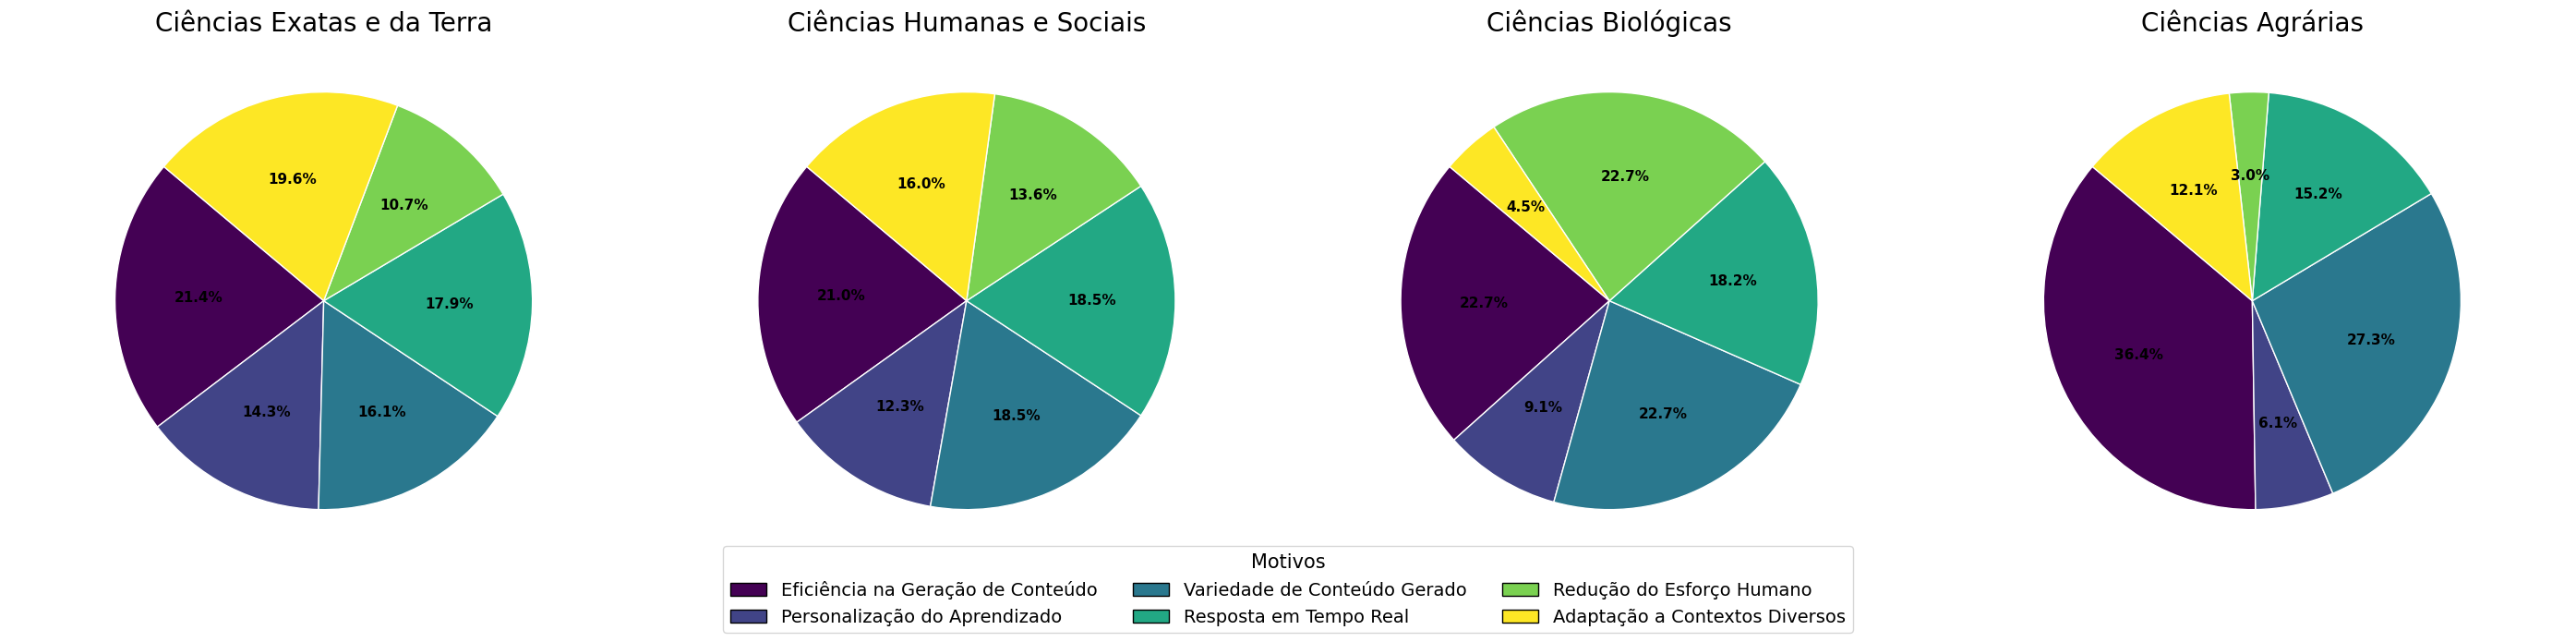

In [139]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Nome da coluna com a área agrupada (ajuste se necessário)
coluna_area = 'Área de Estudo Agrupada'

# Motivos que estamos procurando nas respostas
motivos = [
    'Eficiência na Geração de Conteúdo',
    'Personalização do Aprendizado',
    'Variedade de Conteúdo Gerado',
    'Resposta em Tempo Real',
    'Redução do Esforço Humano',
    'Adaptação a Contextos Diversos'
]

# Obter áreas únicas
areas = df[coluna_area].dropna().unique()
n_areas = len(areas)

# Configurar o grid para subplots lado a lado
fig, axs = plt.subplots(1, n_areas, figsize=(7 * n_areas, 7))

# Paleta de cores base
cmap = plt.get_cmap('viridis')
cores_base = cmap(np.linspace(0, 1, len(motivos)))

# Garantir que axs seja sempre uma lista (mesmo que só tenha uma área)
if n_areas == 1:
    axs = [axs]

for idx, area in enumerate(areas):
    ax = axs[idx]

    # Filtra as respostas daquela área
    respostas_area = df[df[coluna_area] == area]['Se sim, selecione os motivos que justificam por que a IA Generativa é considerada melhor que os métodos tradicionais'].dropna()

    # Contar os motivos nas respostas
    contagem_motivos_area = {motivo: respostas_area.str.contains(motivo, case=True).sum() for motivo in motivos}

    # Criar DataFrame
    df_motivos_area = pd.DataFrame({
        'Motivo': list(contagem_motivos_area.keys()),
        'Contagem': list(contagem_motivos_area.values())
    })

    df_motivos_area = df_motivos_area[df_motivos_area['Contagem'] > 0]  # Remove contagens zeradas

    if df_motivos_area.empty:
        ax.axis('off')
        ax.set_title(f'{area}\n(Sem respostas)')
        continue

    # Cores compatíveis com a ordem original
    cores_ativas = [cores_base[motivos.index(m)] for m in df_motivos_area['Motivo']]

    # Gráfico de pizza
    wedges, texts, autotexts = ax.pie(
        df_motivos_area['Contagem'],
        labels=None,
        colors=cores_ativas,
        autopct='%1.1f%%',
        startangle=140,
        wedgeprops=dict(edgecolor='white')
    )

    # Ajustes de texto
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontsize(11)
        autotext.set_fontweight('bold')

    ax.set_title(f'{area}', fontsize=20)
    ax.axis('equal')

# Legenda única abaixo de todos os gráficos
handles_legenda = [
    mpatches.Patch(facecolor=cores_base[i], edgecolor='black', label=motivos[i])
    for i in range(len(motivos))
]

fig.legend(handles=handles_legenda, title='Motivos', loc='lower center', ncol=3, fontsize=14, title_fontsize=15)

# Ajustes finais
plt.tight_layout(rect=[0, 0.1, 1, 1])  # Deixa espaço abaixo para a legenda
plt.show()


### Satisfação com a Utilização de IA Generativa

C:\Users\Luise\AppData\Local\Temp\ipykernel_16992\3646131567.py:81: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=cores_base[i], label=categorias[i], edgecolor='black')


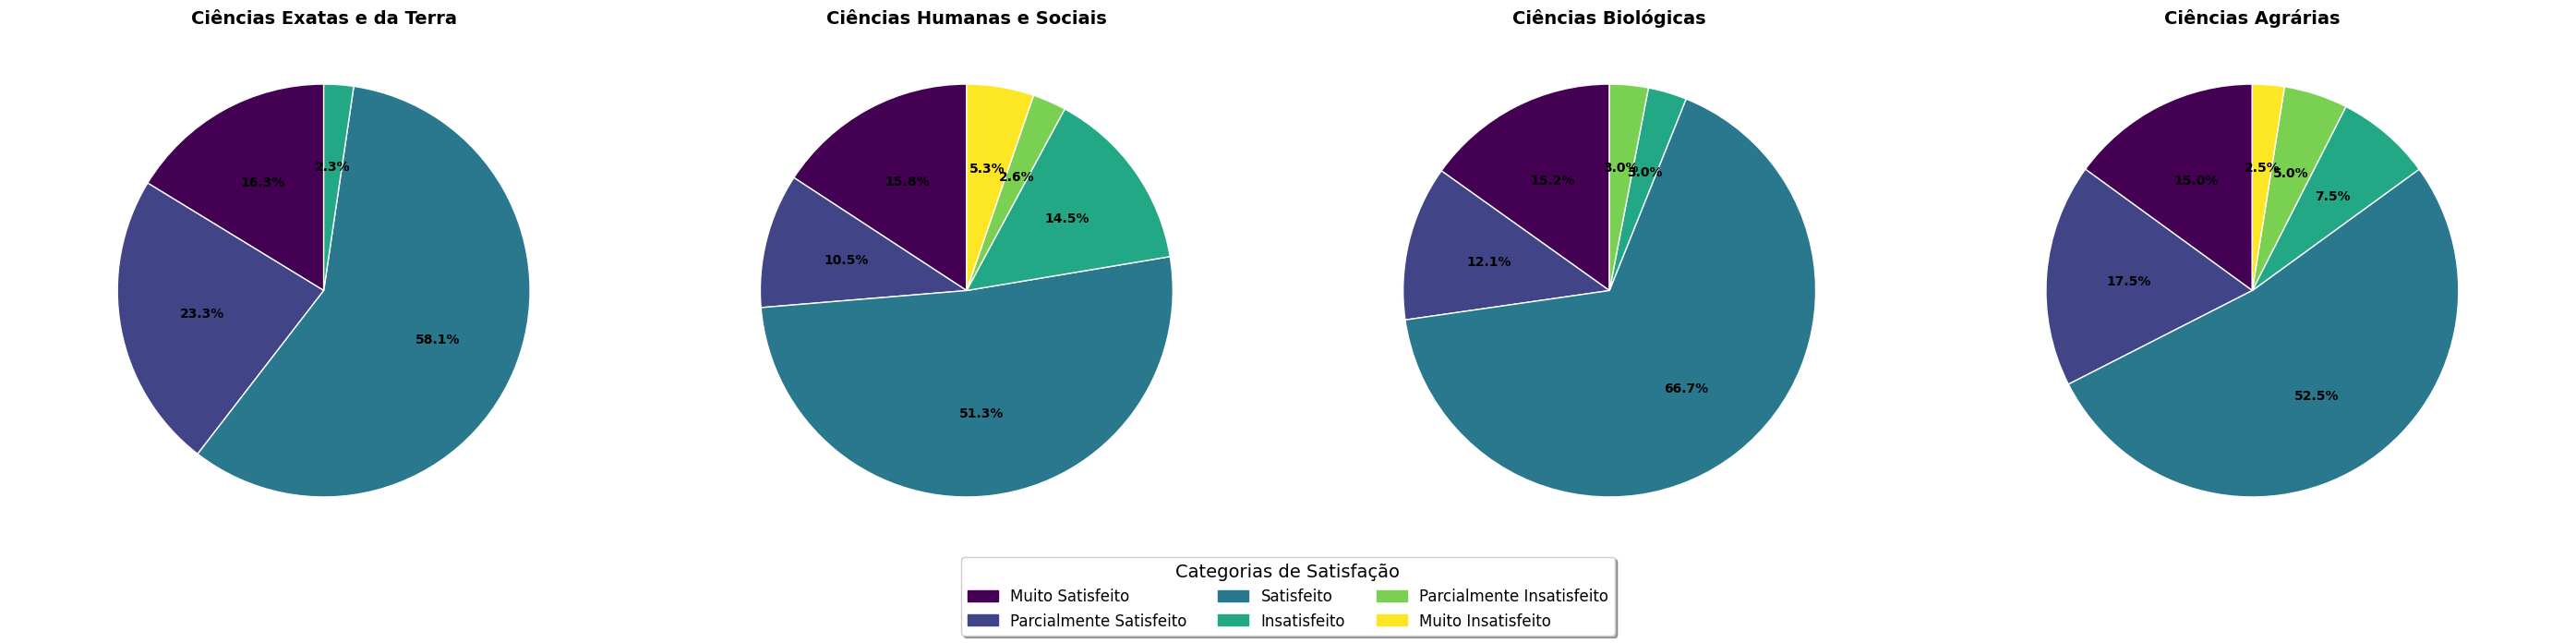

In [ ]:
# Coluna da área agrupada (ajuste se necessário)
coluna_area = 'Área de Estudo Agrupada'

# Categorias de satisfação
categorias = [
    'Muito Satisfeito',
    'Parcialmente Satisfeito',
    'Satisfeito',
    'Insatisfeito',
    'Parcialmente Insatisfeito',
    'Muito Insatisfeito'
]

# Paleta de cores fixa e ordenada
cmap = plt.get_cmap('viridis')
cores_base = cmap(np.linspace(0, 1, len(categorias)))

# Função para gerar rótulos de porcentagem
def func_autopct(pct):
    return f'{pct:.1f}%'

# Obter áreas únicas
areas = df[coluna_area].dropna().unique()
n_areas = len(areas)

# Configurar a figura e os subplots
fig, axs = plt.subplots(1, n_areas, figsize=(7 * n_areas, 7))

# Garante que axs seja uma lista mesmo com 1 subplot
if n_areas == 1:
    axs = [axs]

for idx, area in enumerate(areas):
    ax = axs[idx]

    # Filtra respostas da área
    respostas_area = df[df[coluna_area] == area]['No geral, como você avalia sua experiência ao utilizar ferramentas de IA generativa no ensino superior?'].dropna()

    # Contar categorias
    contagem = {
        cat: respostas_area.str.contains(r'\b' + cat + r'\b', case=True).sum()
        for cat in categorias
    }

    df_area = pd.DataFrame({
        'Categoria': list(contagem.keys()),
        'Contagem': list(contagem.values())
    })
    df_area['Porcentagem'] = (df_area['Contagem'] / df_area['Contagem'].sum()) * 100
    df_area = df_area[df_area['Contagem'] > 0]

    if df_area.empty:
        ax.axis('off')
        ax.set_title(f'{area}\n(Sem respostas)')
        continue

    # Cores para categorias presentes
    cores_ativas = [cores_base[categorias.index(cat)] for cat in df_area['Categoria']]

    # Gráfico de pizza
    wedges, texts, autotexts = ax.pie(
        df_area['Contagem'],
        labels=None,
        autopct=func_autopct,
        startangle=90,
        colors=cores_ativas,
        textprops={'weight': 'bold', 'color': 'black'},
        wedgeprops=dict(edgecolor='white')
    )

    # Ajustar manualmente rótulos de porcentagem pequenos (<1%)
    for i, text in enumerate(autotexts):
        if df_area['Porcentagem'].iloc[i] < 1:
            text.set_position((text.get_position()[0] * 1.4, text.get_position()[1] * 1.4))

    ax.set_title(f'{area}', fontsize=20)
    ax.axis('equal')

# Criar legenda única abaixo dos gráficos
patches_list = [
    mpatches.Patch(color=cores_base[i], label=categorias[i], edgecolor='black')
    for i in range(len(categorias))
]
fig.legend(
    handles=patches_list, 
    title="Categorias de Satisfação", 
    loc='lower center', 
    ncol=3, 
    fontsize=12, 
    title_fontsize=14,
    fancybox=True,
    shadow=True
    )

# Ajuste de layout
plt.tight_layout(rect=[0, 0.12, 1, 1])  # deixa espaço inferior para legenda
plt.show()


### Resposta aberta com opniões sobre IAG

C:\Users\Luise\AppData\Local\Temp\ipykernel_16992\922044134.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  legend_elements = [mpatches.Patch(facecolor=colors[i], label=f'{categoria} ({porcentagens[i]:.1f}%)') for i, categoria in enumerate(contagem_categorias.index)]


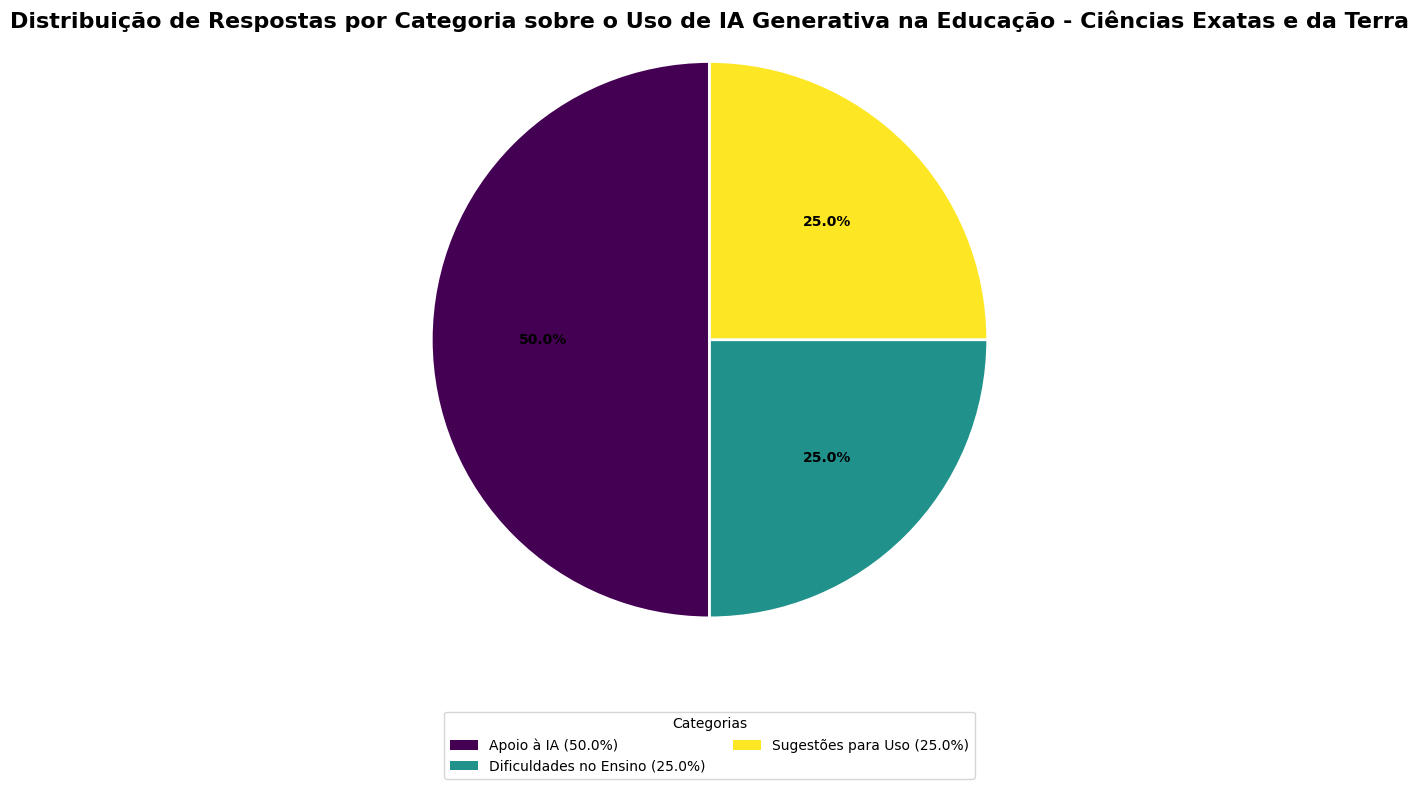


Contagem de respostas por categoria em Ciências Exatas e da Terra:
Apoio à IA: 1
Cautela com a IA: 0
Dificuldades no Ensino: 0
Sugestões para Uso: 1


C:\Users\Luise\AppData\Local\Temp\ipykernel_16992\922044134.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  legend_elements = [mpatches.Patch(facecolor=colors[i], label=f'{categoria} ({porcentagens[i]:.1f}%)') for i, categoria in enumerate(contagem_categorias.index)]


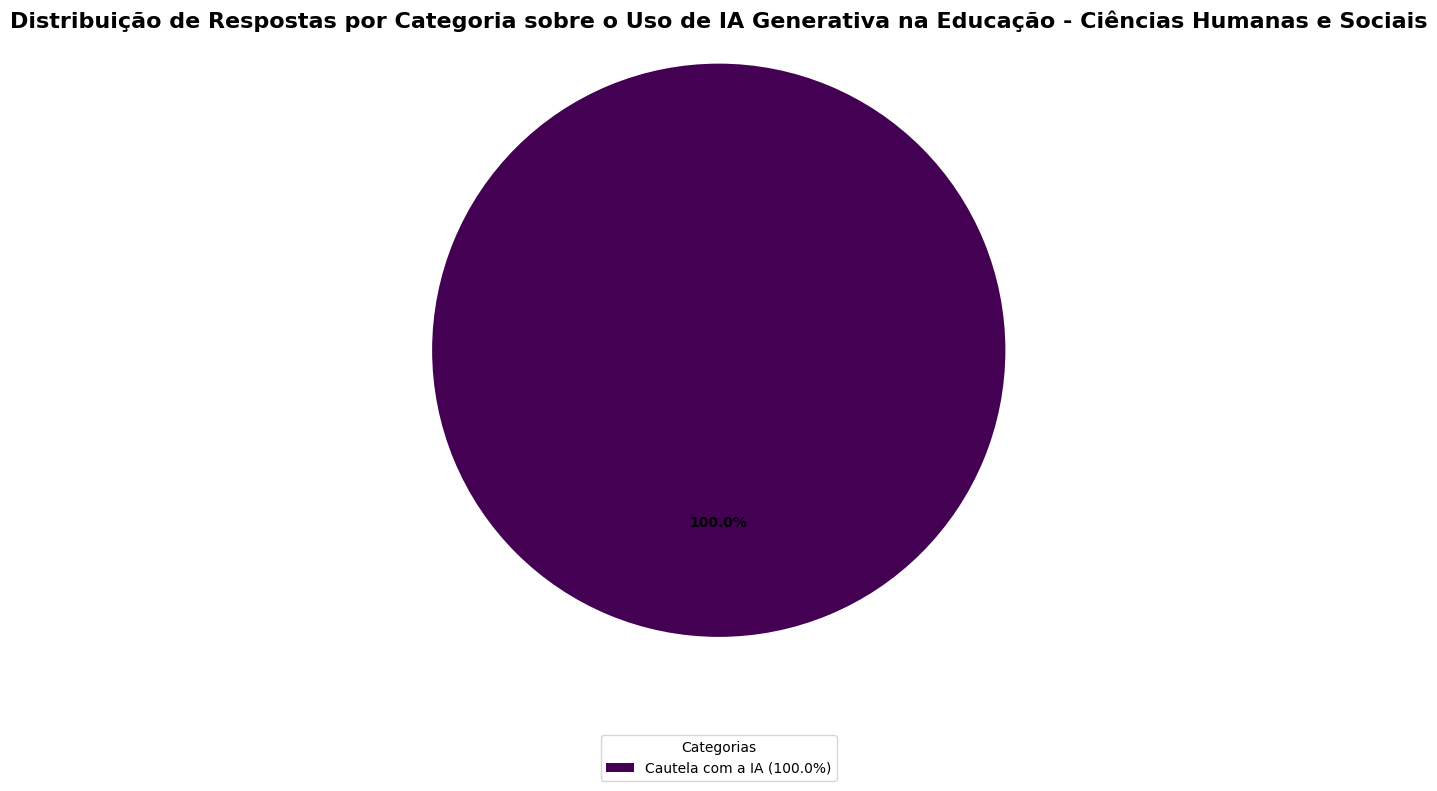


Contagem de respostas por categoria em Ciências Humanas e Sociais:
Apoio à IA: 0
Cautela com a IA: 0
Dificuldades no Ensino: 0
Sugestões para Uso: 0


C:\Users\Luise\AppData\Local\Temp\ipykernel_16992\922044134.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  legend_elements = [mpatches.Patch(facecolor=colors[i], label=f'{categoria} ({porcentagens[i]:.1f}%)') for i, categoria in enumerate(contagem_categorias.index)]


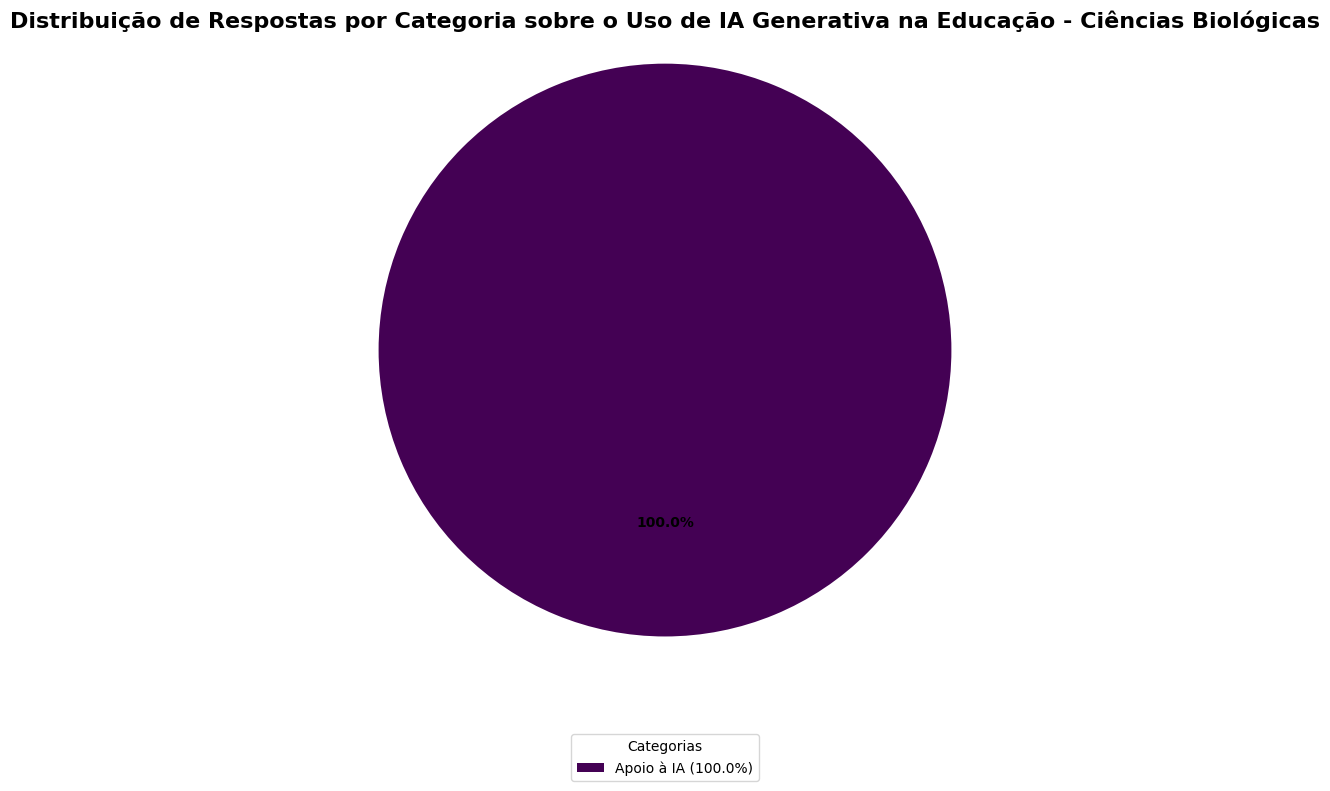


Contagem de respostas por categoria em Ciências Biológicas:
Apoio à IA: 0
Cautela com a IA: 0
Dificuldades no Ensino: 0
Sugestões para Uso: 0


C:\Users\Luise\AppData\Local\Temp\ipykernel_16992\922044134.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  legend_elements = [mpatches.Patch(facecolor=colors[i], label=f'{categoria} ({porcentagens[i]:.1f}%)') for i, categoria in enumerate(contagem_categorias.index)]


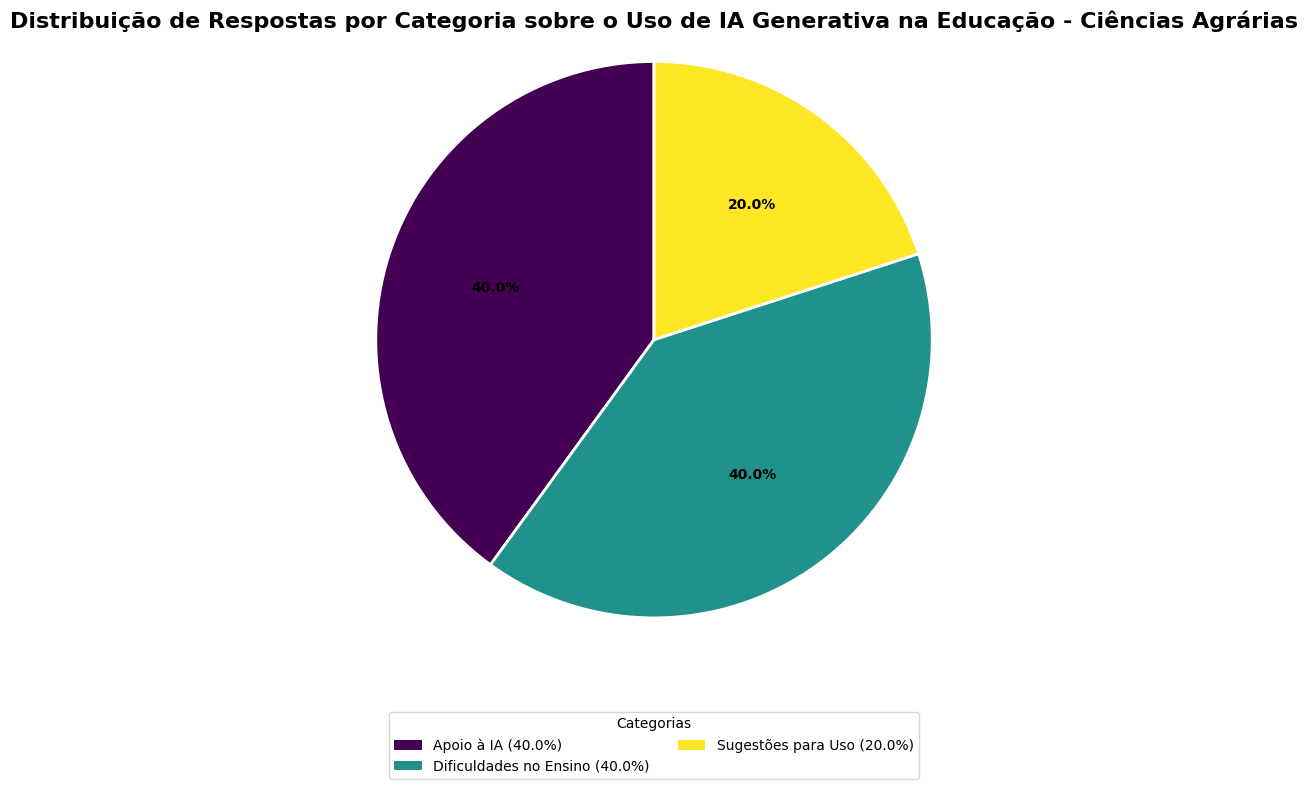


Contagem de respostas por categoria em Ciências Agrárias:
Apoio à IA: 0
Cautela com a IA: 0
Dificuldades no Ensino: 1
Sugestões para Uso: 1


In [ ]:
# Definindo as categorias e suas palavras-chave
categorias = {
    'Apoio à IA': ['ajuda', 'suporte', 'ótima ferramenta', 'benefícios', 'melhoria'],
    'Cautela com a IA': ['plágio', 'uso inadequado', 'dependência', 'cuidado'],
    'Dificuldades no Ensino': ['dificuldades', 'provas', 'nível de dificuldade'],
    'Sugestões para Uso': ['sugestão', 'recomenda', 'pode melhorar', 'educação'],
}

# Função para gerar o gráfico de pizza por área
def gerar_grafico_pizza_por_area(df, area):
    respostas = df[df['Área de Estudo Agrupada'] == area]['Você tem alguma sugestão ou comentário adicional sobre o uso de ferramentas de IA generativa na educação superior? (Resposta aberta)']

    # Criar uma lista para armazenar as linhas do DataFrame
    linhas = []

    # Filtrar as respostas em categorias
    for categoria, palavras in categorias.items():
        for palavra in palavras:
            # Usando \b para buscar apenas a palavra exata
            respostas_filtradas = respostas[respostas.str.contains(r'\b' + palavra + r'\b', case=False, na=False)]
            for resposta in respostas_filtradas:
                linhas.append({'Categoria': categoria, 'Resposta': resposta})

    # Criar o DataFrame a partir da lista de linhas
    df_categorias = pd.DataFrame(linhas)

    # Contar quantas respostas existem em cada categoria
    contagem_categorias = df_categorias['Categoria'].value_counts()

    # Calcular as porcentagens
    porcentagens = (contagem_categorias / contagem_categorias.sum()) * 100

    # Cores para o gráfico
    colors = plt.cm.viridis(np.linspace(0, 1, len(contagem_categorias)))

    # Criar o gráfico de pizza com rótulos em negrito
    plt.figure(figsize=(8, 8))
    plt.pie(contagem_categorias, labels=None, autopct='%1.1f%%', startangle=90,
            colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'weight': 'bold'})  # Porcentagens em negrito

    # Criar uma legenda com as categorias e as cores correspondentes usando patches
    legend_elements = [mpatches.Patch(facecolor=colors[i], label=f'{categoria} ({porcentagens[i]:.1f}%)') for i, categoria in enumerate(contagem_categorias.index)]
    plt.legend(handles=legend_elements, title="Categorias", loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)

    # Adicionar título
    # plt.title(f'Distribuição de Respostas por Categoria sobre o Uso de IA Generativa na Educação - {area}', fontsize=16, fontweight='bold')

    # Garantir que o gráfico seja circular
    plt.axis('equal')

    # Exibir o gráfico
    plt.tight_layout()
    plt.show()

# Obter áreas únicas
areas_estudo = df['Área de Estudo Agrupada'].dropna().unique()
# Loop para gerar gráfico por área
for area in areas_estudo:
    gerar_grafico_pizza_por_area(df, area)
    # Contagem de respostas por categoria
    respostas_area = df[df['Área de Estudo Agrupada'] == area]['Você tem alguma sugestão ou comentário adicional sobre o uso de ferramentas de IA generativa na educação superior? (Resposta aberta)']
    contagem_respostas = {categoria: respostas_area.str.contains(r'\b' + palavra + r'\b', case=False, na=False).sum() for categoria, palavras in categorias.items() for palavra in palavras}

    # Imprimir contagem de respostas por categoria
    print(f"\nContagem de respostas por categoria em {area}:")
    for categoria, contagem in contagem_respostas.items():
        print(f"{categoria}: {contagem}")
